In [ ]:
import pandas as pd
import ast # Import the Abstract Syntax Tree module for safe evaluation
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import contextily as cx # Library to fetch basemaps
import geopandas as gpd # Library for geographic data structures

Loading of the datasets into separate dataframes, the dataframes will later be joined in order to get a single dataframe containing all the information regarding both the tracks and the aritsts performing them. We also print the head of each dataframe to get an initial idea about the different attributes and how they are populated

In [25]:
artists = 'dataset/artists.csv'
tracks = 'dataset/tracks.csv'

index_col = 0
df_artists = pd.read_csv(artists, sep=';', index_col=index_col)
df_tracks = pd.read_csv(tracks, index_col=index_col)

pd.set_option('display.max_columns', None)

In [26]:
df_artists.head(10)

,name,gender,birth_date,birth_place,nationality,description,active_start,active_end,province,region,country,latitude,longitude
id_author,,,,,,,,,,,,,
ART82291002,99 posse,M,NaN,NaN,NaN,gruppo musicale italiano,1991-01-01,NaN,NaN,Campania,NaN,NaN,NaN
ART53496045,achille lauro,M,1990-07-11,Verona,Italia,cantautore e rapper italiano (1990-),2012-01-01,NaN,Verona,Veneto,Italia,45.442498,10.985738
ART18853907,alfa,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Liguria,NaN,NaN,NaN
ART64265460,anna pepe,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Liguria,NaN,NaN,NaN
ART75741740,articolo 31,M,NaN,NaN,NaN,gruppo musicale hip hop italiano,1990-01-01,NaN,NaN,Lombardia,NaN,NaN,NaN
ART24123617,babaman,M,1975-08-08,Rho,Italia,cantante italiano,NaN,NaN,Milano,Lombardia,Italia,45.528878,9.041560
ART40229749,baby k,F,1983-02-05,Singapore,Italia,cantautrice e rapper italiana (1983-),2007-01-01,NaN,NaN,NaN,NaN,45.080627,7.670717
ART56320683,bassi maestro,M,1973-08-03,Milano,Italia,"rapper, disc jockey, beatmaker e produttore di...",1988-01-01,NaN,Milano,Lombardia,Italia,45.464194,9.189635
ART19605256,beba,F,NaN,NaN,NaN,cognome,NaN,NaN,NaN,Piemonte,NaN,NaN,NaN


In [27]:
df_tracks.head(10)

,id_artist,name_artist,full_title,title,featured_artists,primary_artist,language,album,stats_pageviews,swear_IT,swear_EN,swear_IT_words,swear_EN_words,year,month,day,n_sentences,n_tokens,tokens_per_sent,char_per_tok,lexical_density,avg_token_per_clause,bpm,centroid,rolloff,flux,rms,zcr,flatness,spectral_complexity,pitch,loudness,album_name,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,album_image,id_album,lyrics,modified_popularity
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
TR934808,ART04205421,Rosa Chemical,​polka 2 :-/ by Rosa Chemical (Ft. Ernia & Guè),​polka 2 :-/,"Ernia, Guè",Rosa Chemical,pl,FOREVER AND EVER,196033.0,13,6,"['cazzo', 'cesso', 'coglioni', 'figa', 'merda'...","['bitch', 'fuck', 'porno', 'pussy']",2021.0,4.0,2.0,102.0,911.0,8.931373,4.170455,0.575284,8.133929,135.32,0.1858,2895.7767,1.4499,0.1786,0.1046,0.8202,25.7148,2311.1779,17.8675,FOREVER AND EVER,2021-04-09,album,1.0,3.0,207761.0,True,46.0,https://i.scdn.co/image/ab67616d0000b2736d5e14...,ALB115557,"Oplà, ah\nBdope, chiama due b—\n\nMi candidere...",False
TR760029,ART04205421,Rosa Chemical,POLKA by Rosa Chemical (Ft. Thelonious B.),POLKA,Thelonious B.,Rosa Chemical,en,FOREVER AND EVER,164450.0,9,12,"['cazzo', 'culo', 'frocio', 'puttana', 'sega',...","['escort', 'negro', 'sex', 'sexy', 'shit']",2020.0,3.0,6.0,56.0,675.0,12.053571,4.280851,0.648936,12.500000,129.37,0.2071,3378.4605,1.3533,0.2020,0.1175,0.6739,29.1089,1892.1924,21.4595,FOREVER AND EVER,2021-04-09,album,1.0,3.0,207761.0,True,46.0,https://i.scdn.co/image/ab67616d0000b2736d5e14...,ALB115557,"Greg Willen, non dormire\n(Brr-poh)\n\nT-T-Tro...",False
TR916821,ART04205421,Rosa Chemical,​britney ;-) by Rosa Chemical (Ft. MamboLosco ...,​britney ;-),"MamboLosco, RADICAL",Rosa Chemical,en,FOREVER AND EVER,58313.0,16,12,"['bastardo', 'cazzo', 'culo', 'merda', 'troia']","['bastardo', 'bitch', 'bitches', 'cock', 'fuck']",2021.0,2.0,19.0,88.0,758.0,8.613636,4.075251,0.556856,8.422222,133.68,0.1833,2037.4847,1.3822,0.2552,0.0800,0.7842,26.9762,2484.3503,29.4590,FOREVER AND EVER,2021-04-09,album,1.0,1.0,193544.0,True,39.0,https://i.scdn.co/image/ab67616d0000b2736d5e14...,ALB115557,"Mothz\nYeah, yeah, yeah-yeah\nBdope, chiama du...",False
TR480968,ART04205421,Rosa Chemical,CEO by Rosa Chemical (Ft. Taxi B),CEO,Taxi B,Rosa Chemical,it,OKAY OKAY !! - EP,39890.0,8,3,"['cazzo', 'culo', 'fottere', 'merda', 'pompino...","['fuck', 'porno', 'shit']",2019.0,3.0,8.0,37.0,382.0,10.324324,4.023881,0.534328,6.701754,162.22,0.1048,1156.3781,1.5499,0.1971,0.0436,0.8764,14.2956,2984.6109,20.5067,OKAY OKAY 2,2025-05-16,single,1.0,2.0,169000.0,True,47.0,https://i.scdn.co/image/ab67616d0000b27367c03d...,ALB730959,Designer sui vestiti penso di essere un outlet...,False
TR585039,ART04205421,Rosa Chemical,LONDRA by Rosa Chemical (Ft. Rkomi),LONDRA,Rkomi,Rosa Chemical,en,FOREVER AND EVER,35432.0,1,0,['cazzo'],[],2020.0,5.0,29.0,48.0,429.0,8.937500,3.922857,0.491429,8.411765,105.87,0.1421,1693.4542,1.0886,0.2369,0.0695,0.8571,36.6951,1572.0499,25.3407,FOREVER,2020-05-28,album,1.0,8.0,194779.0,True,41.0,https://i.scdn.co/image/ab67616d0000b273fcdb60...,ALB436151,"Bdope (Yeah)\n\nVuole solo me, non fare la gel...",False
TR550335,ART04205421,Rosa Chemical,BOHEME by Rosa Chemical,BOHEME,NaN,Rosa Chemical,it,FOREVER AND EVER,34443.0,2,0,['cazzo'],[],2020.0,5.0,21.0,62.0,387.0,6.241935,4.160606,0.506061,6.450000,92.02,0.1115,1158.8606,1.0737,0.2334,0.0463,0.8943,23.0539,1943.1810,25.2680,FOREVER,2020-05-28,album,1.0,11.0,200329.0,True,29.0,https://i.scdn.co/image/ab67616d0000b273fcdb60...,ALB436151,Uh-uh\nAh-li-ah\nUh-uh\n\nSenti la pioggia che...,False
TR170793,ART04205421,Rosa Chemical,LOBBY WAY by Rosa Chemical,LOBBY WAY,NaN,Rosa Chemical,it,FOREVER AND EVER,29265.0,5,2,"['cazzo', 'cesso', 'scopare']","['bitches', 'sex']",2072,4.0,17.0,82.0,680.0,8.292683,3.817680,0.438306,12.142857,129.82,0.1575,1787.9302,1.2172,0.2632,0.0708,0.8592,29.9563,2111.8930,29.2586,FOREVER,2020-05-28,album,1.0

In [28]:
df_tracks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11166 entries, TR934808 to TR552777
Data columns (total 44 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_artist             11166 non-null  object 
 1   name_artist           11166 non-null  object 
 2   full_title            11166 non-null  object 
 3   title                 11166 non-null  object 
 4   featured_artists      3517 non-null   object 
 5   primary_artist        11166 non-null  object 
 6   language              11061 non-null  object 
 7   album                 9652 non-null   object 
 8   stats_pageviews       4642 non-null   float64
 9   swear_IT              11166 non-null  int64  
 10  swear_EN              11166 non-null  int64  
 11  swear_IT_words        11166 non-null  object 
 12  swear_EN_words        11166 non-null  object 
 13  year                  10766 non-null  object 
 14  month                 9969 non-null   float64
 15  day           

In [29]:
df_artists.info()

<class 'pandas.core.frame.DataFrame'>
Index: 104 entries, ART82291002 to ART83631935
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          104 non-null    object 
 1   gender        104 non-null    object 
 2   birth_date    73 non-null     object 
 3   birth_place   72 non-null     object 
 4   nationality   71 non-null     object 
 5   description   86 non-null     object 
 6   active_start  50 non-null     object 
 7   active_end    0 non-null      float64
 8   province      70 non-null     object 
 9   region        101 non-null    object 
 10  country       70 non-null     object 
 11  latitude      72 non-null     float64
 12  longitude     72 non-null     float64
dtypes: float64(3), object(10)
memory usage: 11.4+ KB


## Data casting

The initial inspection revealed that a majority of the attributes across both dataframes were automatically assigned the generic object data type. This misclassification is likely a consequence of type heterogeneity within the columns, often caused by the presence of missing values (e.g., NumPy's NaN), erroneous non-numeric entries, or mixed data formats.

Before proceeding with imputation or feature engineering, a preliminary data cleaning phase is necessary. We will systematically enforce type consistency by casting attributes to their appropriate data types based on their underlying semantics (e.g., converting strings representing dates to datetime, or numeric strings to float or int). This step is foundational, as correct data types are essential for accurate analysis, proper handling of missing values, and efficient memory usage.

---

In [30]:
df_artists['gender'] = df_artists['gender'].astype('category')
df_artists['nationality'] = df_artists['nationality'].astype('category')
df_artists['country'] = df_artists['country'].astype('category')
df_artists['region'] = df_artists['region'].astype('category')
df_artists['province'] = df_artists['province'].astype('category')
df_artists['birth_place'] = df_artists['birth_place'].astype('category')
df_artists['birth_date'] = pd.to_datetime(df_artists['birth_date'], errors='coerce')
df_artists['active_start'] = pd.to_datetime(df_artists['active_start'], errors='coerce')
df_artists['description'] = df_artists['description'].astype('string')
df_artists['name'] = df_artists['name'].astype('string')

In [31]:
df_tracks['id_artist'] = df_tracks['id_artist'].astype('category')
df_tracks['id_album'] = df_tracks['id_album'].astype('category')
df_tracks['language'] = df_tracks['language'].astype('category')
df_tracks['album_type'] = df_tracks['album_type'].astype('category')
df_tracks['stats_pageviews'] = df_tracks['stats_pageviews'].astype('Int64')
df_tracks['year'] = pd.to_numeric(df_tracks['year'], errors = 'coerce').astype('Int64')
df_tracks['month'] = pd.to_numeric(df_tracks['month'], errors = 'coerce').astype('Int64')
df_tracks['day'] = pd.to_numeric(df_tracks['day'], errors = 'coerce').astype('Int64')
df_tracks['popularity'] = pd.to_numeric(df_tracks['popularity'], errors = 'coerce').astype('Int64')
df_tracks['n_sentences'] = df_tracks['n_sentences'].astype('Int64')
df_tracks['n_tokens'] = df_tracks['n_tokens'].astype('Int64')
df_tracks['swear_IT'] = df_tracks['n_sentences'].astype('Int64')
df_tracks['swear_EN'] = df_tracks['n_sentences'].astype('Int64')
df_tracks['disc_number'] = df_tracks['disc_number'].astype('Int64')
df_tracks['track_number'] = df_tracks['track_number'].astype('Int64')
df_tracks['explicit'] = df_tracks['explicit'].astype('boolean')
df_tracks['modified_popularity'] = df_tracks['modified_popularity'].astype('boolean')
df_tracks['album_release_date'] = pd.to_datetime(df_tracks['album_release_date'], errors='coerce')
df_tracks['name_artist'] = df_tracks['name_artist'].astype('string')
df_tracks['full_title'] = df_tracks['full_title'].astype('string')
df_tracks['title'] = df_tracks['title'].astype('string')
df_tracks['primary_artist'] = df_tracks['primary_artist'].astype('string')
df_tracks['album_name'] = df_tracks['album_name'].astype('string')
df_tracks['album'] = df_tracks['album'].astype('string')
df_tracks['album_image'] = df_tracks['album_image'].astype('string')
df_tracks['lyrics'] = df_tracks['lyrics'].astype('string')


In [ ]:
# Assuming your DataFrame is df_tracks and it's already loaded

def safe_literal_eval(value):
    """
    Safely converts a string representation of a list into a Python list.
    Handles NaN/missing values by returning an empty list or pd.NA.
    """
    if pd.isna(value) or value in (None, 'NaN', ''):
        # Return an empty list for missing values if you plan to iterate over it
        return []
    try:
        # Use ast.literal_eval for safe conversion of string-to-list
        return ast.literal_eval(value)
    except (ValueError, SyntaxError):
        # Handle cases where the string is malformed or not a list structure
        print(f"Warning: Could not convert value: {value}")
        return [] # Default to empty list on failure

# Apply the conversion to both columns
df_tracks['swear_IT_words'] = df_tracks['swear_IT_words'].apply(safe_literal_eval)
df_tracks['swear_EN_words'] = df_tracks['swear_EN_words'].apply(safe_literal_eval)

In [33]:
df_artists.info()

<class 'pandas.core.frame.DataFrame'>
Index: 104 entries, ART82291002 to ART83631935
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   name          104 non-null    string        
 1   gender        104 non-null    category      
 2   birth_date    72 non-null     datetime64[ns]
 3   birth_place   72 non-null     category      
 4   nationality   71 non-null     category      
 5   description   86 non-null     string        
 6   active_start  50 non-null     datetime64[ns]
 7   active_end    0 non-null      float64       
 8   province      70 non-null     category      
 9   region        101 non-null    category      
 10  country       70 non-null     category      
 11  latitude      72 non-null     float64       
 12  longitude     72 non-null     float64       
dtypes: category(6), datetime64[ns](2), float64(3), string(2)
memory usage: 10.7+ KB


In [34]:
df_tracks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11166 entries, TR934808 to TR552777
Data columns (total 44 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id_artist             11166 non-null  category      
 1   name_artist           11166 non-null  string        
 2   full_title            11166 non-null  string        
 3   title                 11166 non-null  string        
 4   featured_artists      3517 non-null   object        
 5   primary_artist        11166 non-null  string        
 6   language              11061 non-null  category      
 7   album                 9652 non-null   string        
 8   stats_pageviews       4642 non-null   Int64         
 9   swear_IT              11090 non-null  Int64         
 10  swear_EN              11090 non-null  Int64         
 11  swear_IT_words        11166 non-null  object        
 12  swear_EN_words        11166 non-null  object        
 13  year       

In [35]:
df_artists.describe()

,birth_date,active_start,active_end,latitude,longitude
count,72,50,0.0,72.000000,72.000000
mean,1987-06-11 17:20:00,2003-04-27 22:33:36,NaN,43.591374,11.060876
min,1967-10-07 00:00:00,1988-01-01 00:00:00,NaN,37.747452,7.525403
25%,1980-08-24 12:00:00,1996-01-01 00:00:00,NaN,41.577547,9.189635
50%,1989-03-12 12:00:00,2004-01-01 00:00:00,NaN,45.067755,9.917118
75%,1993-12-20 18:00:00,2011-01-01 00:00:00,NaN,45.464194,12.482932
max,2002-04-29 00:00:00,2018-01-01 00:00:00,NaN,45.806691,18.225226
std,NaN,NaN,NaN,2.248674,2.591871


In [36]:
df_tracks.describe()

,stats_pageviews,swear_IT,swear_EN,year,month,day,n_sentences,n_tokens,tokens_per_sent,char_per_tok,lexical_density,avg_token_per_clause,bpm,centroid,rolloff,flux,rms,zcr,flatness,spectral_complexity,pitch,loudness,album_release_date,disc_number,track_number,duration_ms,popularity
count,4642.0,11090.0,11090.0,10728.0,9969.0,9843.0,11090.0,11090.0,11090.000000,11090.000000,11090.000000,11090.000000,11102.000000,11102.000000,11102.000000,11102.000000,11102.000000,11102.000000,11102.000000,11102.000000,11102.000000,11102.000000,10827,11088.0,11088.0,1.108800e+04,11137.0
mean,36993.646919,59.399639,59.399639,2012.651286,6.198515,15.808697,59.399639,496.891253,8.672152,4.054416,0.514367,8.002009,114.134841,0.137474,1616.965767,1.258893,0.223965,0.063322,0.859986,27.410247,2256.028782,24.226955,2017-03-13 16:42:25.635910144,1.016685,6.859127,2.035293e+05,855.570172
min,5006.0,1.0,1.0,1900.0,1.0,1.0,1.0,3.0,1.500000,2.000000,0.000000,0.000000,59.970000,0.000000,0.000000,0.000000,0.000000,0.000000,0.109400,0.000000,0.000000,0.000000,1962-04-10 00:00:00,1.0,1.0,1.142600e+04,-954.0
25%,9642.25,46.0,46.0,2009.0,3.0,9.0,46.0,372.0,7.333333,3.866946,0.482353,5.859020,91.910000,0.119200,1222.457200,1.172025,0.186225,0.051000,0.841400,21.881750,2003.341325,18.779500,2013-12-11 00:00:00,1.0,2.0,1.701310e+05,16.0
50%,19099.5,58.0,58.0,2016.0,6.0,16.0,58.0,491.0,8.404762,4.012709,0.511719,6.764171,106.975000,0.137200,1551.018550,1.257100,0.229700,0.061700,0.882450,27.330850,2241.157450,24.666850,2018-09-07 00:00:00,1.0,6.0,1.966725e+05,32.0
75%,42011.75,73.0,73.0,2021.0,10.0,23.0,73.0,615.0,9.431527,4.168686,0.542450,8.090909,134.650000,0.155100,1935.570650,1.346875,0.267600,0.074100,0.913075,32.978475,2493.492250,30.010175,2022-05-18 00:00:00,1.0,10.0,2.271840e+05,47.0
max,1971207.0,437.0,437.0,2100.0,12.0,31.0,437.0,3089.0,400.000000,12.000000,1.000000,660.000000,738.270000,0.298200,8635.954200,1.928500,0.621900,0.268300,1.000000,61.222500,3993.020300,81.947800,2025-06-18 00:00:00,5.0,54.0,3.753057e+06,993842.0
std,58406.564657,24.711996,24.711996,33.288337,3.482992,8.881989,24.711996,209.187612,5.675602,0.445958,0.061583,14.577876,26.827124,0.028131,567.646409,0.137123,0.064592,0.017972,0.109106,8.441590,382.134853,8.648780,NaN,0.138903,5.191472,8.825641e+04,22503.161207


## Missing Values Analysis

After merging the `tracks` and `artists` datasets, we conduct a preliminary audit to assess data quality and completeness.

### 1. Sparsity Heatmap
We visualize the distribution of null values using a binary heatmap:
* **<span style="color:orange">Orange</span>**: Data Present
* **<span style="color:black">Black</span>**: Data Missing

This allows us to instantly spot systematic gaps (e.g., specific metadata fields missing for entire groups of artists).

### 2. Quantitative Ranking
We calculate the percentage of missing values for every column. Features with significant incompleteness (listed below) will require specific imputation strategies or exclusion during the data cleaning phase.

In [37]:
df = df_tracks.join(df_artists, on='id_artist')

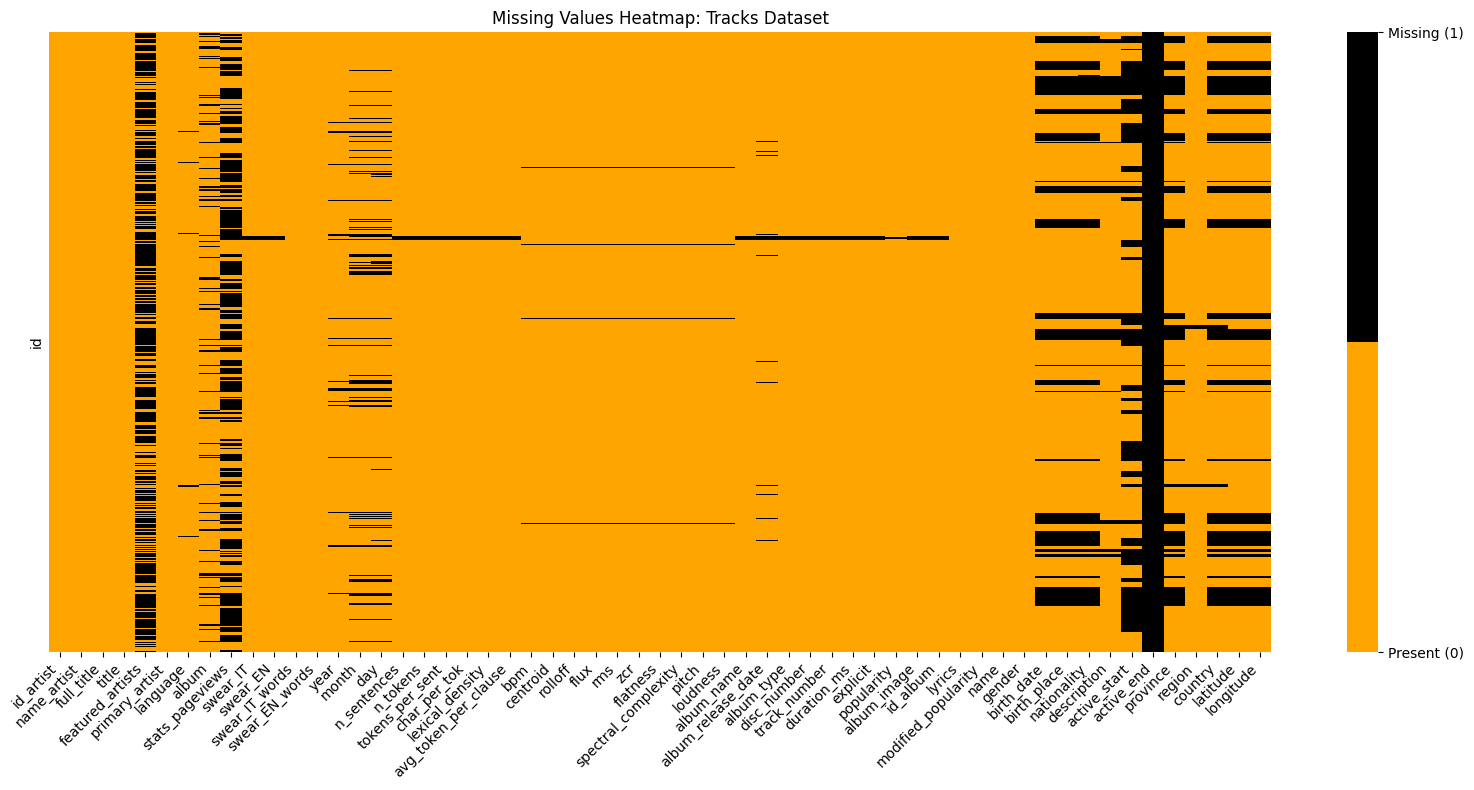

Top 15 Columns with Highest Incompleteness:
---------------------------------------------
active_end                     | 100.00%
featured_artists               |  68.50%
stats_pageviews                |  58.43%
active_start                   |  41.21%
province                       |  24.17%
country                        |  24.17%
nationality                    |  23.37%
longitude                      |  23.09%
birth_date                     |  23.09%
birth_place                    |  23.09%
latitude                       |  23.09%
album                          |  13.56%
day                            |  11.85%
month                          |  10.72%
description                    |  10.19%


In [ ]:
plt.figure(figsize=(16, 8))

# 1. Correct way to create a discrete color map
# [0] = Orange (Present), [1] = Black (Missing)
cmap = ListedColormap(['#FFA500', '#000000']) 

# 2. Plot the heatmap
# Use vmin=0 and vmax=1 to ensure the binary scale maps correctly to your colors
ax = sns.heatmap(df.isnull(), 
                 yticklabels=False, 
                 xticklabels=True, 
                 vmin=0, 
                 vmax=1,
                 cbar_kws={'ticks': [0, 1]}, 
                 cmap=cmap)

# 3. Rename the legend labels for clarity
ax.collections[0].colorbar.set_ticklabels(['Present (0)', 'Missing (1)'])

# 4. Improve X-axis label visibility
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title('Missing Values Heatmap: Tracks Dataset')
plt.tight_layout()
plt.show()

# Calculate the percentage of missing values for each column
missing_percentages = df.isnull().mean() * 100

# Sort in descending order and take the top 10
top_10_missing = missing_percentages.sort_values(ascending=False).head(15)

# Print the results formatted for your report
print("Top 15 Columns with Highest Incompleteness:")
print("-" * 45)
for col, val in top_10_missing.items():
    print(f"{col:30} | {val:6.2f}%")

## Feature Distribution Analysis

Having analyzed missing values and standardized the data types, we now examine the statistical properties of the numerical features.

In this step, we generate histograms and density plots for all continuous and discrete variables to gain insight into:
* **Central Tendency:** Identifying the "center" of the data (mean/mode).
* **Spread & Skewness:** Visualizing the variability and asymmetry of the distributions.
* **Outlier Detection:** Spotting potential anomalies or extreme values that deviate from the norm.

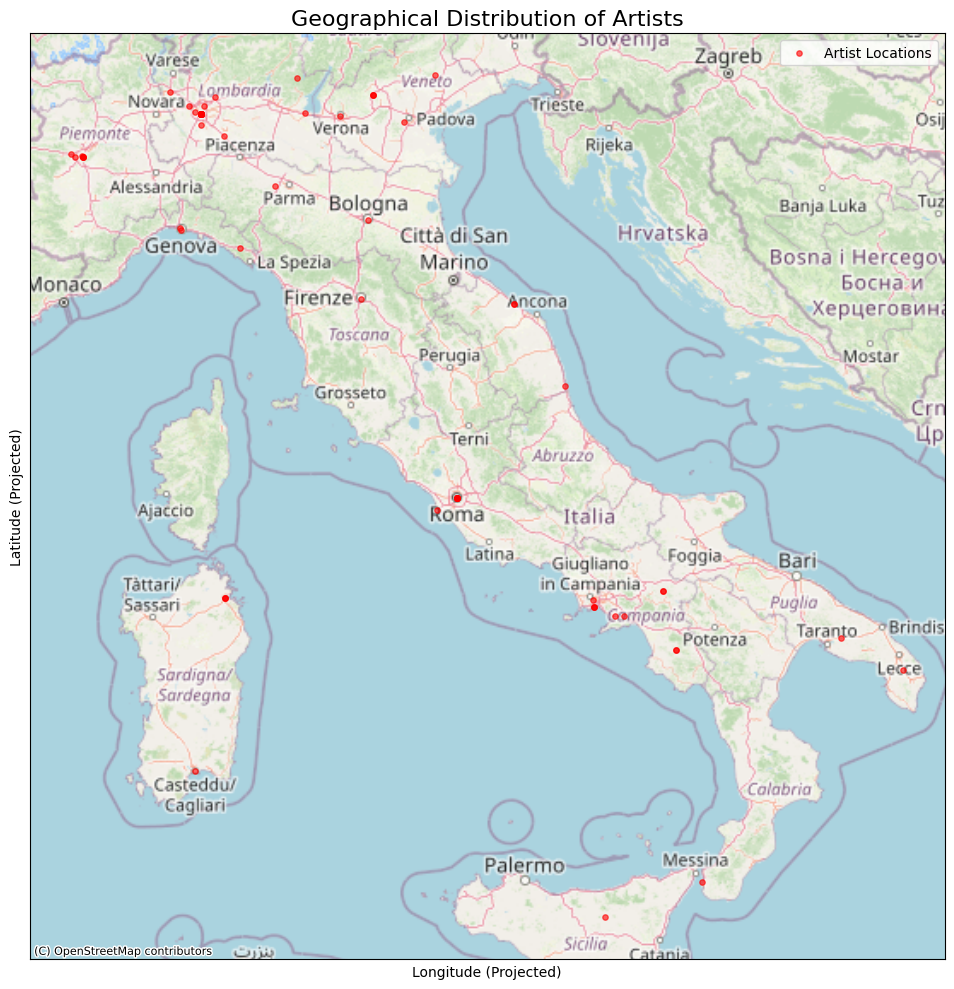

In [39]:
# --- 1. Create a GeoDataFrame ---
# GeoPandas is built on top of Pandas and uses shapely for geometry.
# We convert the regular DataFrame to a GeoDataFrame.
try:
    # Filter out any rows where coordinates are missing
    geo_df = pd.DataFrame({
        'latitude': df_artists['latitude'],
        'longitude': df_artists['longitude']
    }).dropna()

    if geo_df.empty:
        print("Error: Latitude or longitude columns are missing or entirely null. Cannot create map.")
    else:
        # Create a geometry column from the latitude and longitude columns
        # This is the crucial step for spatial visualization
        gdf = gpd.GeoDataFrame(
            geo_df, 
            geometry=gpd.points_from_xy(geo_df.longitude, geo_df.latitude),
            crs="EPSG:4326" # Standard coordinate system for Lat/Lon
        )
        
        # --- 2. Plotting the Data on a Map ---
        
        # Reproject to Web Mercator (EPSG:3857) for compatibility with contextily basemaps
        gdf_proj = gdf.to_crs(epsg=3857)

        fig, ax = plt.subplots(1, 1, figsize=(10, 10))
        
        # Plot the points (the actual data)
        gdf_proj.plot(
            ax=ax, 
            marker='o', 
            color='red', 
            markersize=15, 
            alpha=0.6,
            label='Artist Locations'
        )
        
        # Add a basemap layer using contextily (this makes it look like a map)
        cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
        
        # Set titles and labels
        ax.set_title("Geographical Distribution of Artists", fontsize=16)
        ax.set_xlabel("Longitude (Projected)")
        ax.set_ylabel("Latitude (Projected)")
        
        # Remove tick labels (since basemaps provide context)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        plt.legend()
        plt.tight_layout()
        plt.show()

except KeyError:
    print("Error: Please verify that 'latitude' and 'longitude' columns exist in your DataFrame (df_artists or df_tracks).")


---------------------------------------------------------------------------------------------------------------------------------

plotting the distribution for attribute: id_artist, else branch (Categorical)


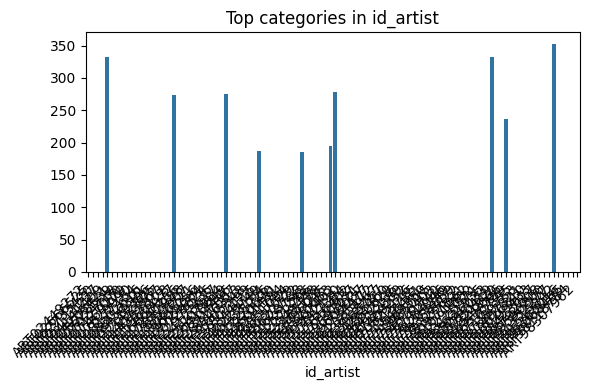

plotting the distribution for attribute: name_artist, else branch (Categorical)


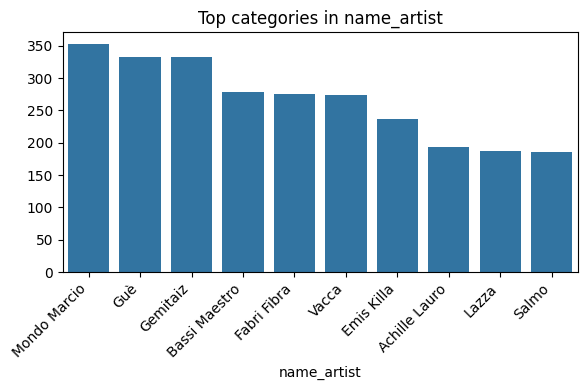

plotting the distribution for attribute: full_title, else branch (Categorical)


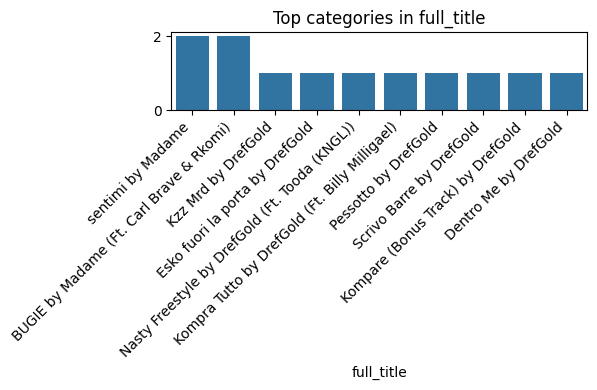

plotting the distribution for attribute: title, else branch (Categorical)


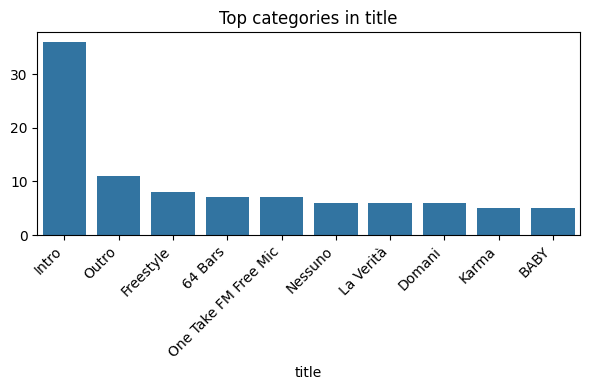

plotting the distribution for attribute: featured_artists, else branch (Categorical)


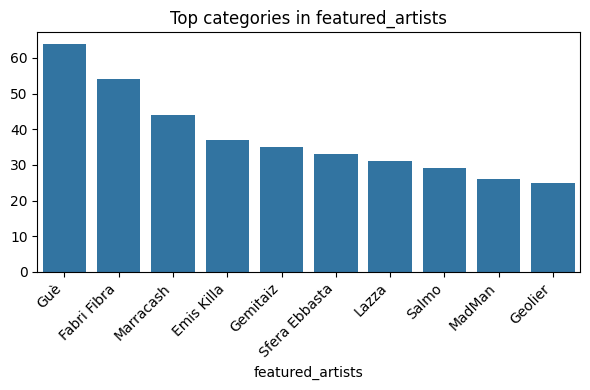

plotting the distribution for attribute: primary_artist, else branch (Categorical)


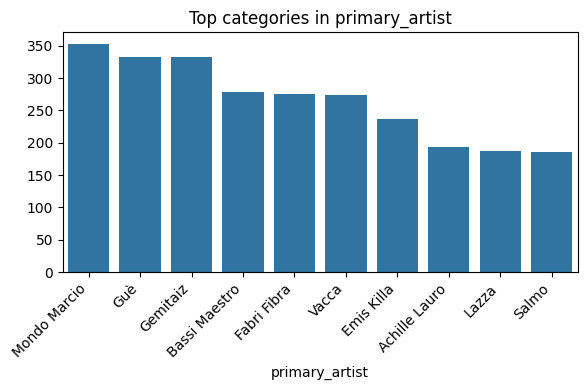

plotting the distribution for attribute: language, else branch (Categorical)


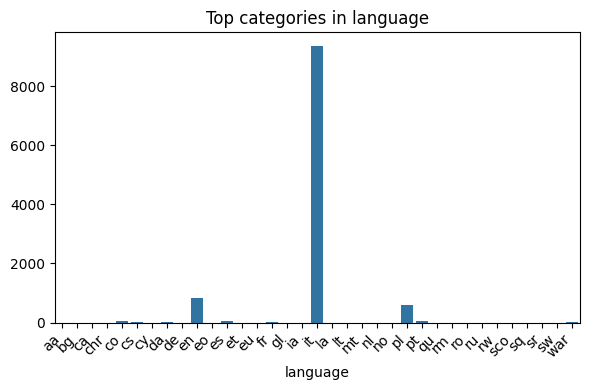

plotting the distribution for attribute: album, else branch (Categorical)


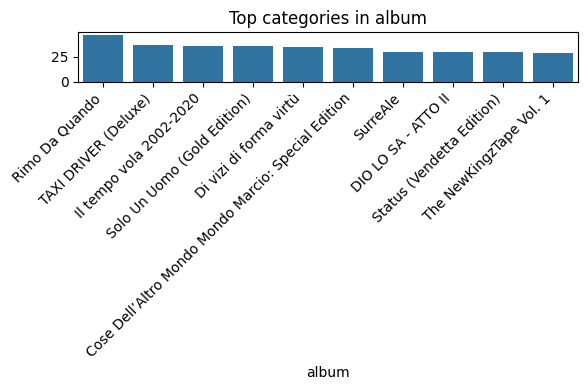

plotting the distribution for attribute: stats_pageviews, if branch (Numerical)


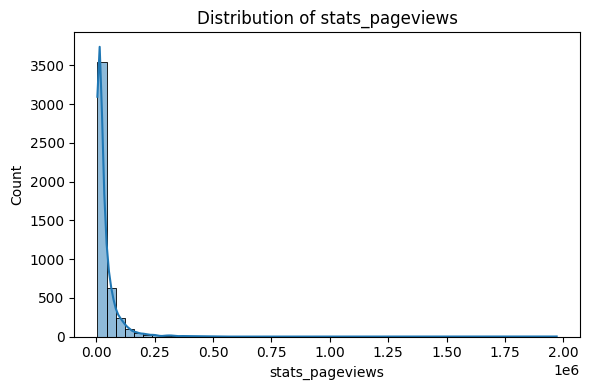

plotting the distribution for attribute: swear_IT, if branch (Numerical)


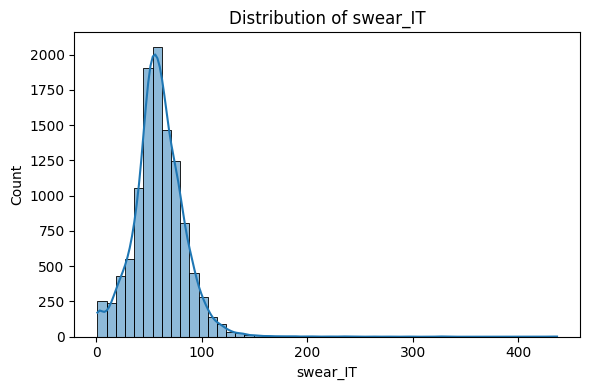

plotting the distribution for attribute: swear_EN, if branch (Numerical)


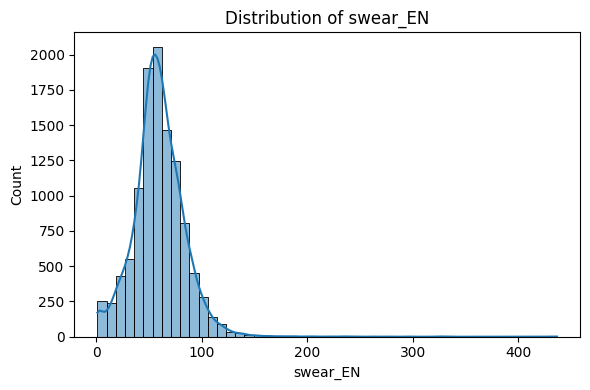

plotting the distribution for attribute: swear_IT_words, else branch (Categorical)
Skipping plot for swear_IT_words: Column contains unhashable types (e.g., Python lists).


<Figure size 600x400 with 0 Axes>

plotting the distribution for attribute: swear_EN_words, else branch (Categorical)
Skipping plot for swear_EN_words: Column contains unhashable types (e.g., Python lists).


<Figure size 600x400 with 0 Axes>

plotting the distribution for attribute: year, if branch (Numerical)


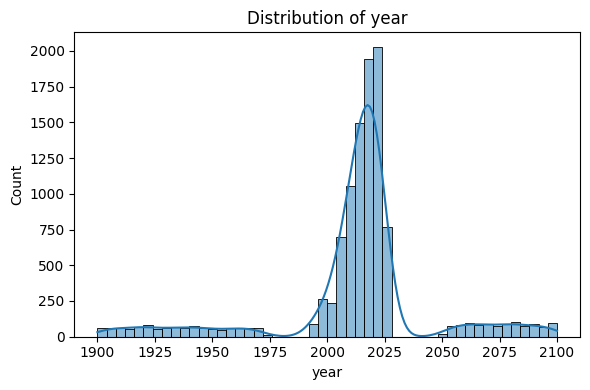

plotting the distribution for attribute: month, if branch (Numerical)


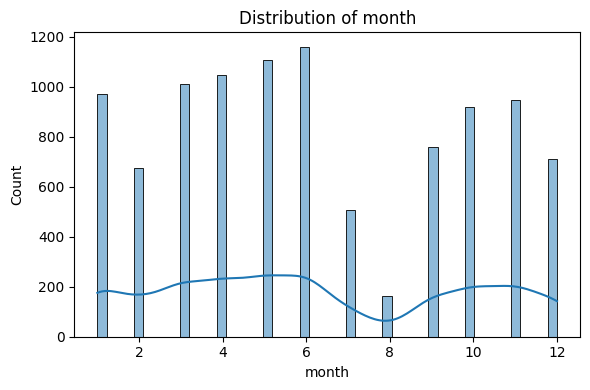

plotting the distribution for attribute: day, if branch (Numerical)


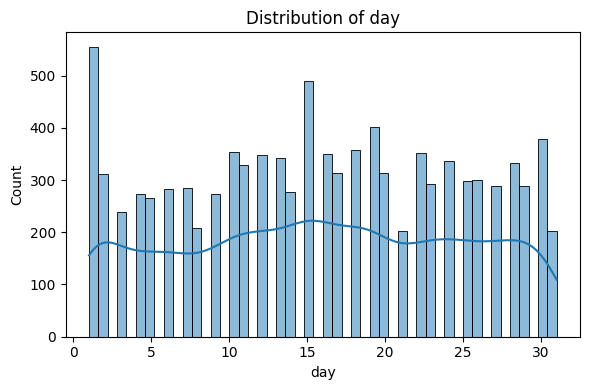

plotting the distribution for attribute: n_sentences, if branch (Numerical)


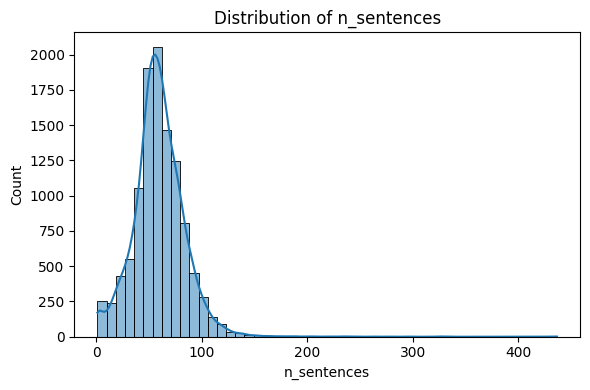

plotting the distribution for attribute: n_tokens, if branch (Numerical)


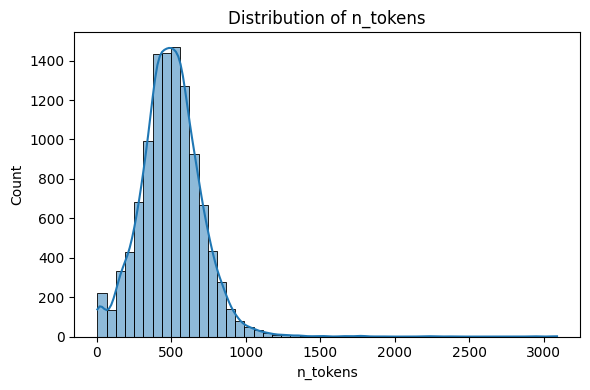

plotting the distribution for attribute: tokens_per_sent, if branch (Numerical)


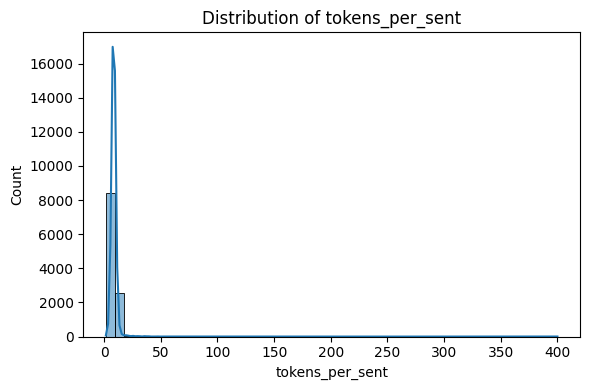

plotting the distribution for attribute: char_per_tok, if branch (Numerical)


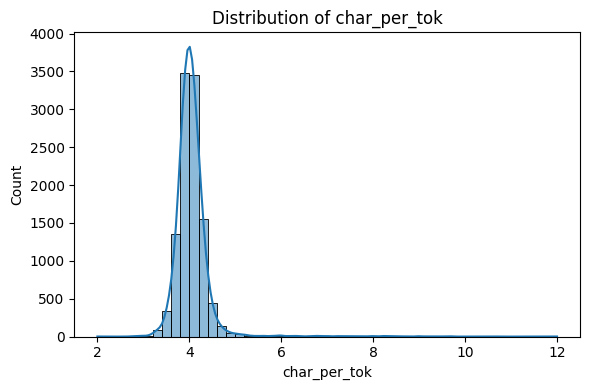

plotting the distribution for attribute: lexical_density, if branch (Numerical)


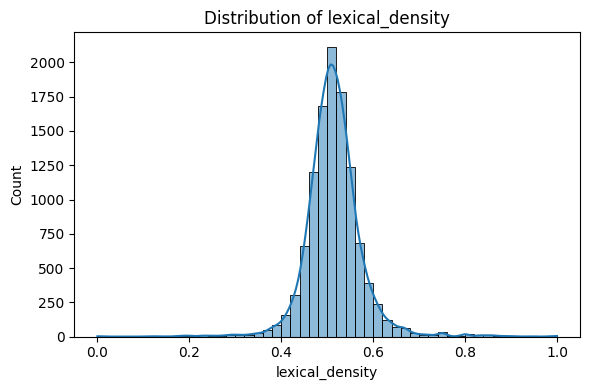

plotting the distribution for attribute: avg_token_per_clause, if branch (Numerical)


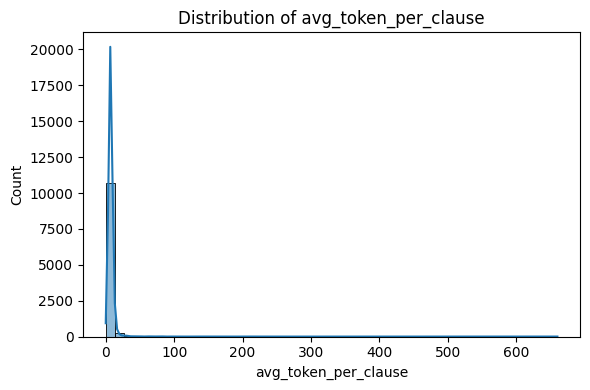

plotting the distribution for attribute: bpm, if branch (Numerical)


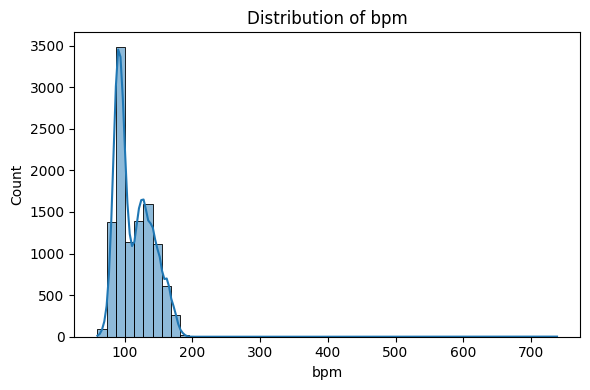

plotting the distribution for attribute: centroid, if branch (Numerical)


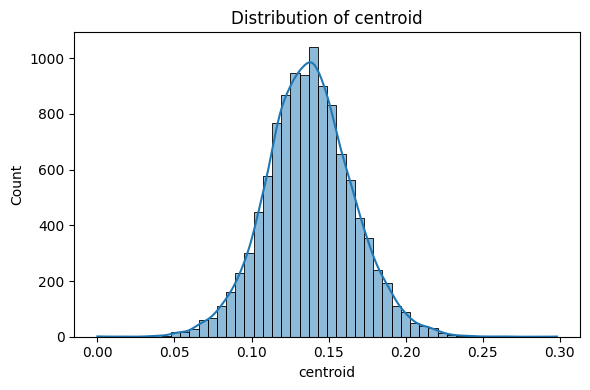

plotting the distribution for attribute: rolloff, if branch (Numerical)


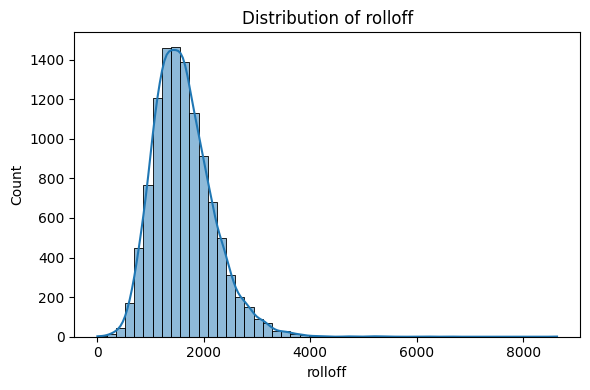

plotting the distribution for attribute: flux, if branch (Numerical)


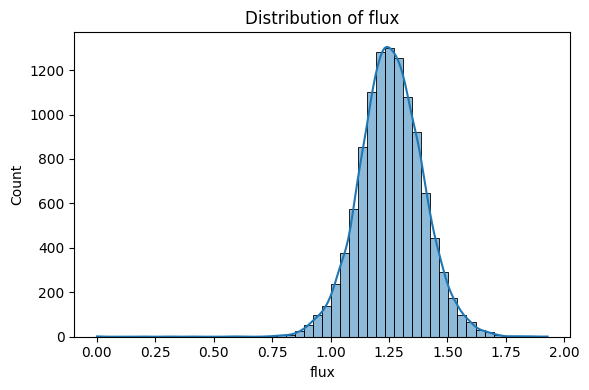

plotting the distribution for attribute: rms, if branch (Numerical)


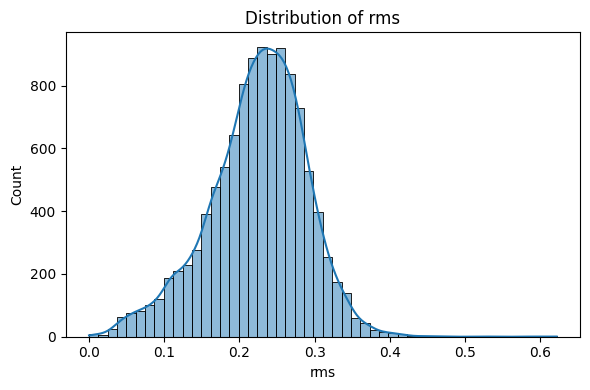

plotting the distribution for attribute: zcr, if branch (Numerical)


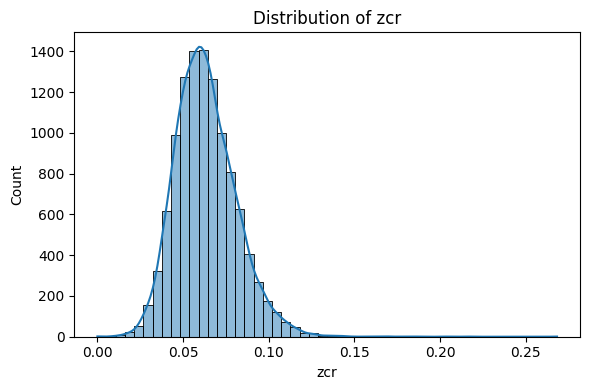

plotting the distribution for attribute: flatness, if branch (Numerical)


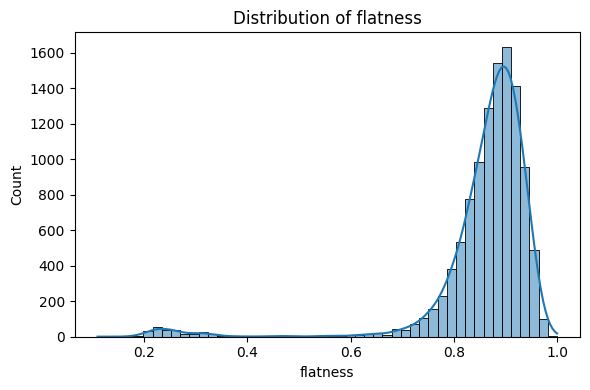

plotting the distribution for attribute: spectral_complexity, if branch (Numerical)


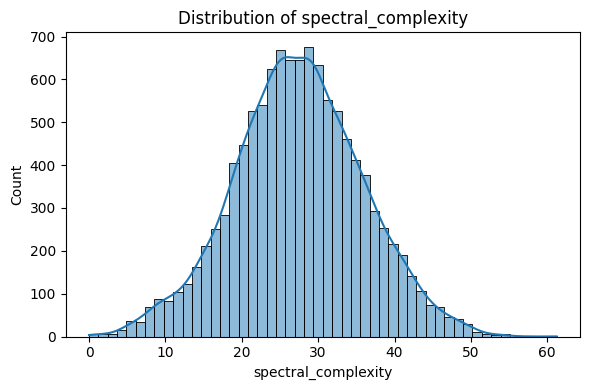

plotting the distribution for attribute: pitch, if branch (Numerical)


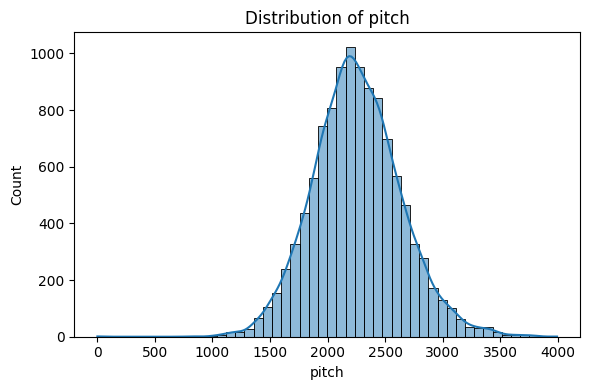

plotting the distribution for attribute: loudness, if branch (Numerical)


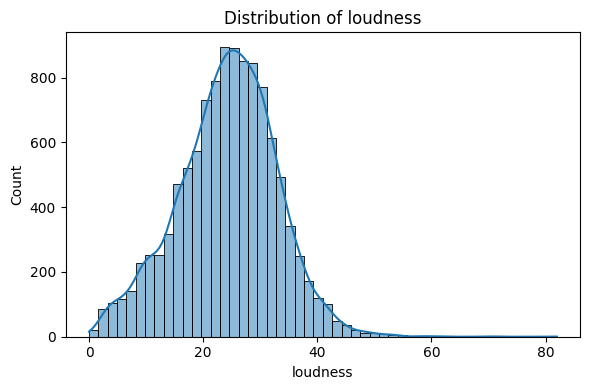

plotting the distribution for attribute: album_name, else branch (Categorical)


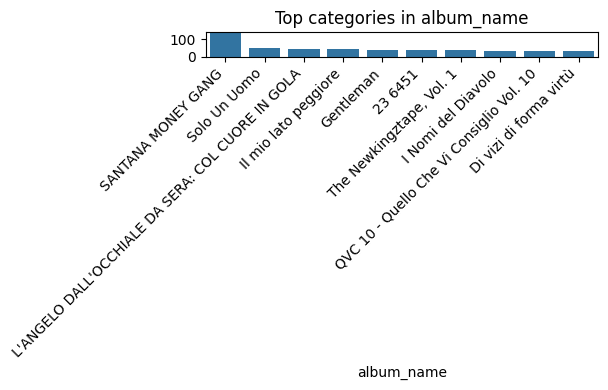

plotting the distribution for attribute: album_release_date, else branch (Categorical)


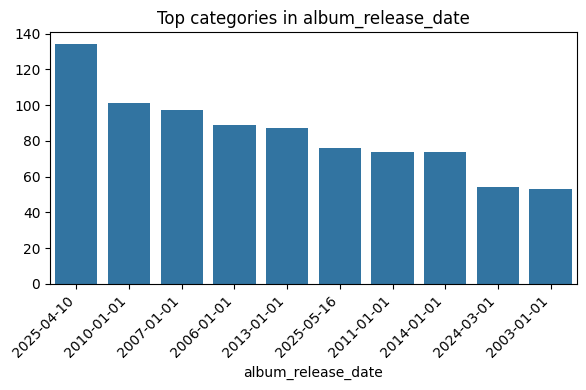

plotting the distribution for attribute: album_type, else branch (Categorical)


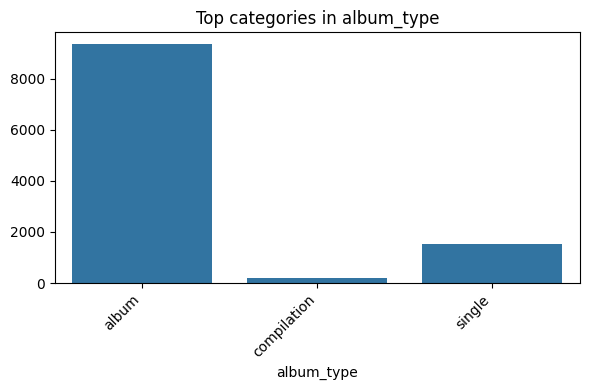

plotting the distribution for attribute: disc_number, if branch (Numerical)


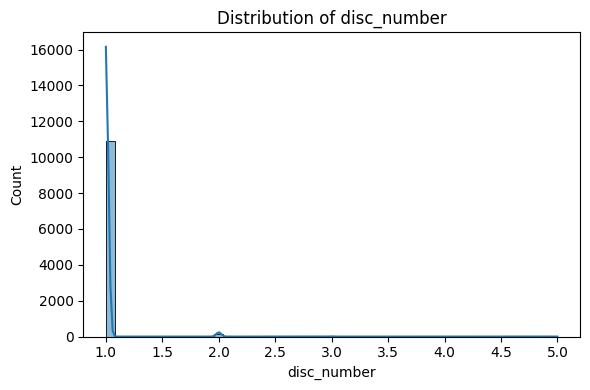

plotting the distribution for attribute: track_number, if branch (Numerical)


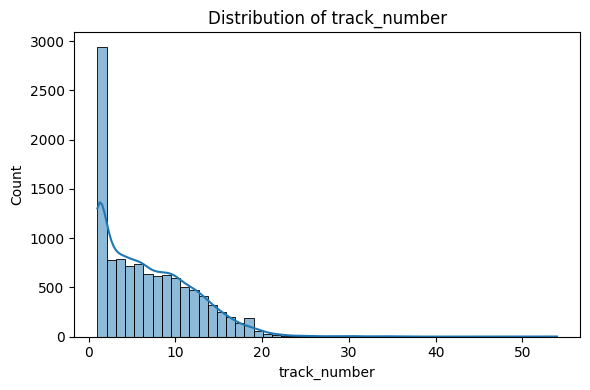

plotting the distribution for attribute: duration_ms, if branch (Numerical)


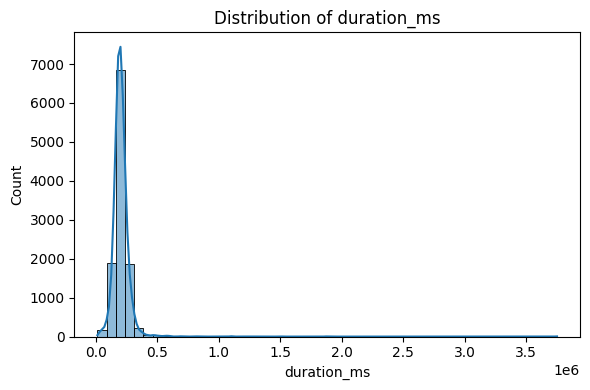

plotting the distribution for attribute: explicit, else branch (Categorical)


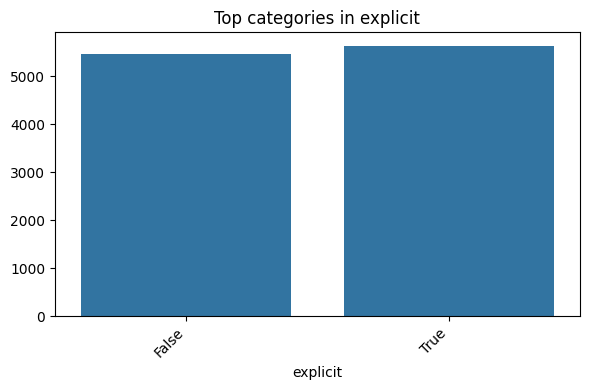

plotting the distribution for attribute: popularity, if branch (Numerical)


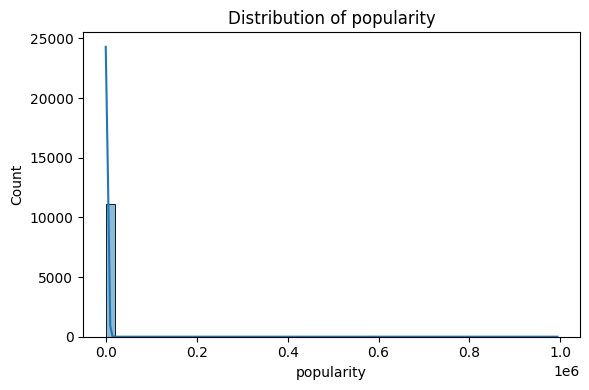

plotting the distribution for attribute: album_image, else branch (Categorical)


/tmp/ipykernel_410768/1535192213.py:39: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


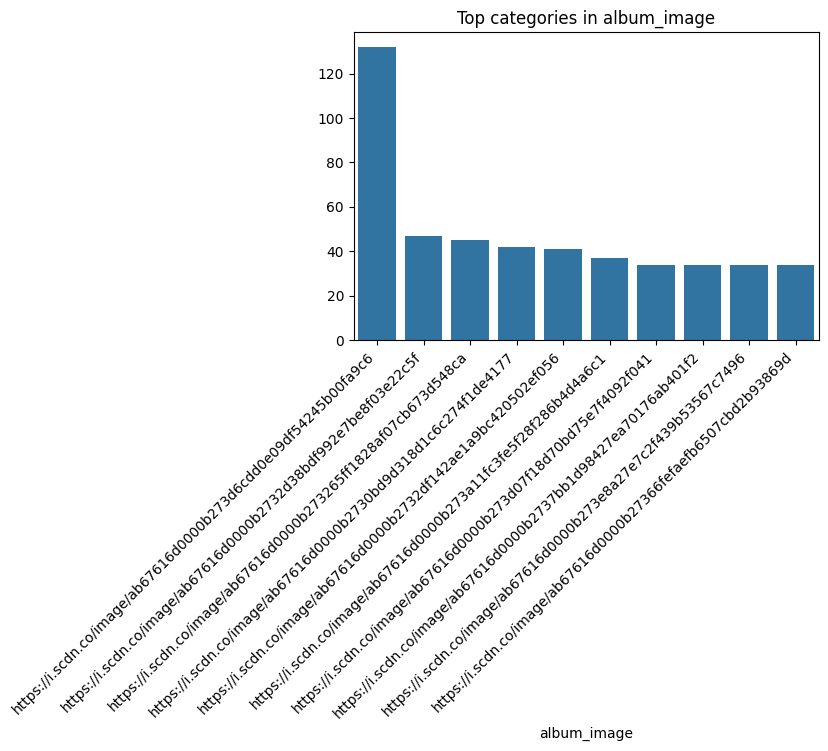

plotting the distribution for attribute: id_album, else branch (Categorical)


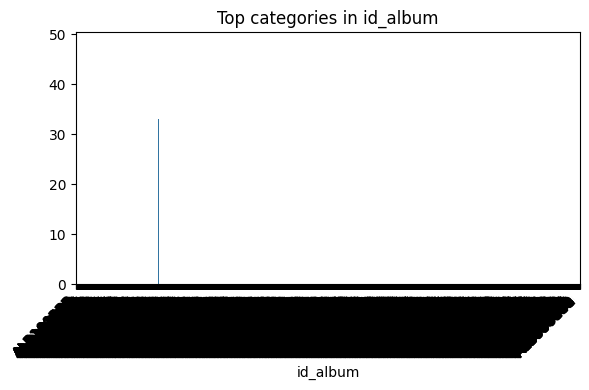

plotting the distribution for attribute: lyrics, else branch (Categorical)


/tmp/ipykernel_410768/1535192213.py:39: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


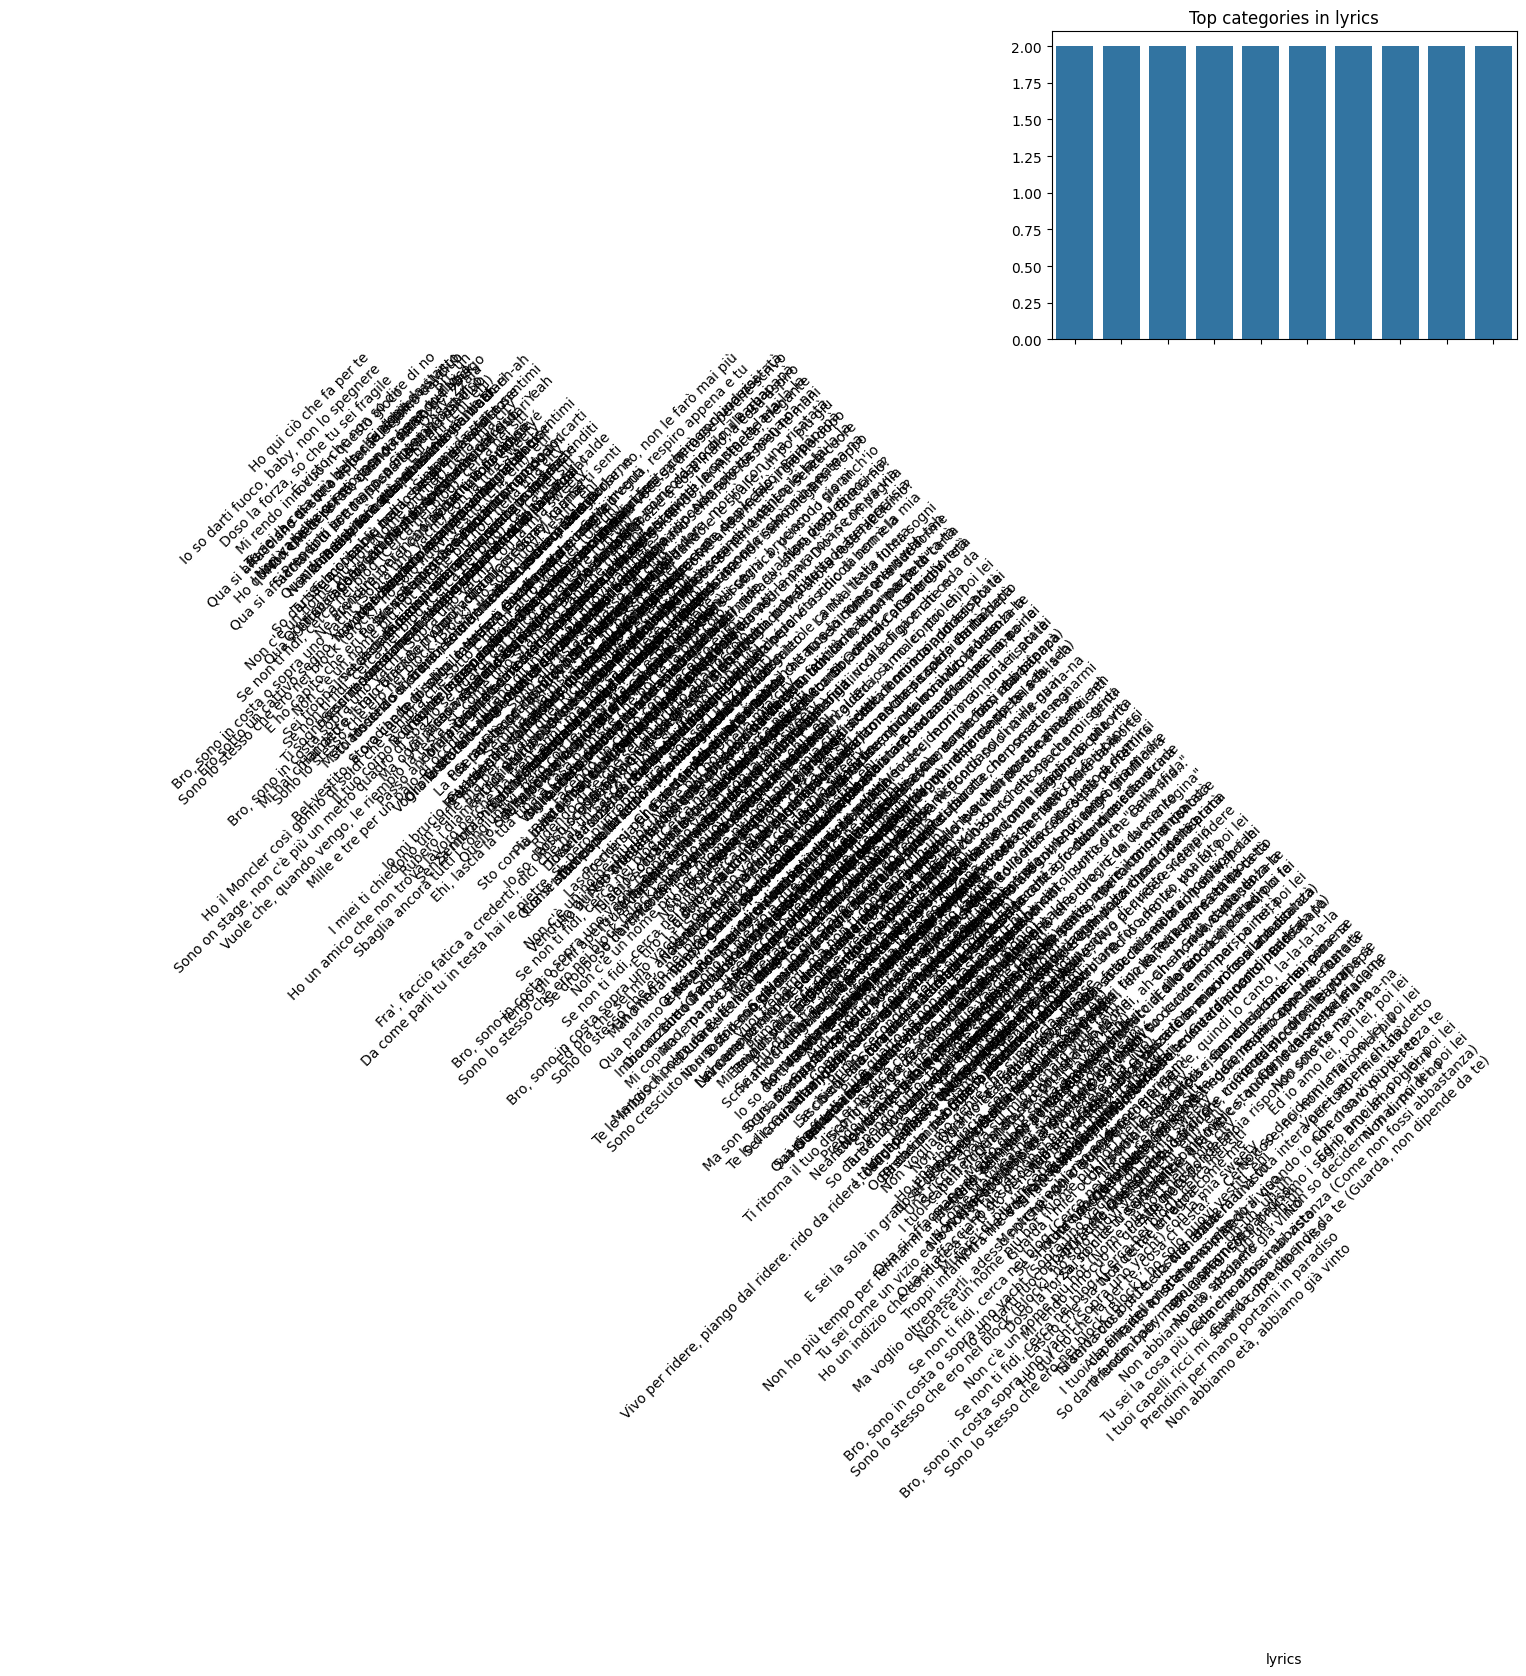

plotting the distribution for attribute: modified_popularity, else branch (Categorical)


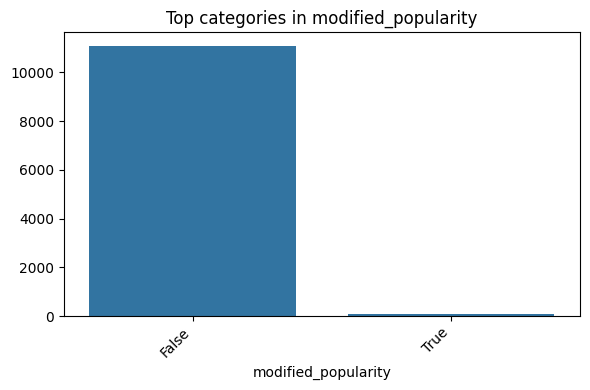

In [40]:
for col in df_tracks.columns:
    plt.figure(figsize=(6,4))
    
    # --- Check for Numerical Columns (includes float64, int64, and Nullable Int64) ---
    # Using .kind in 'fi' is a reliable way to check for all float and integer types
    if df_tracks[col].dtype.kind in 'fi': 
        print(f"plotting the distribution for attribute: {col}, if branch (Numerical)")
        
        data_to_plot = df_tracks[col].dropna()
            
        sns.histplot(data_to_plot, kde=True, bins=50)
        plt.title(f'Distribution of {col}')

    # --- Handle Categorical/Object Columns, using try/except for unhashable types ---
    # We use a try/except to catch the 'unhashable type: list' error gracefully
    else:
        try:
            print(f"plotting the distribution for attribute: {col}, else branch (Categorical)")
            
            # The error occurs here if the column contains Python lists
            counts = df_tracks[col].value_counts().head(10)
            
            # Only proceed if there are values to plot
            if not counts.empty:
                sns.barplot(x=counts.index, y=counts.values)
                plt.title(f'Top categories in {col}')
                plt.xticks(rotation=45, ha='right')
            else:
                print(f"Skipping categorical plot for {col}: Value counts were empty.")

        except TypeError as e:
            # This handles the 'TypeError: unhashable type: 'list'' gracefully
            if 'unhashable type' in str(e):
                print(f"Skipping plot for {col}: Column contains unhashable types (e.g., Python lists).")
            else:
                # Re-raise any other unexpected TypeErrors
                raise e

    plt.tight_layout()
    plt.show()

plotting the distribution for attribute: name, else branch (Categorical)


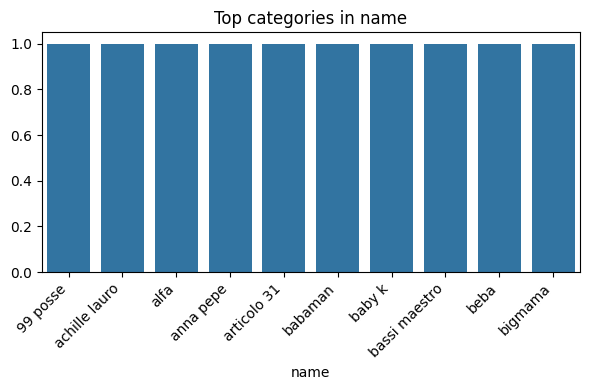

plotting the distribution for attribute: gender, else branch (Categorical)


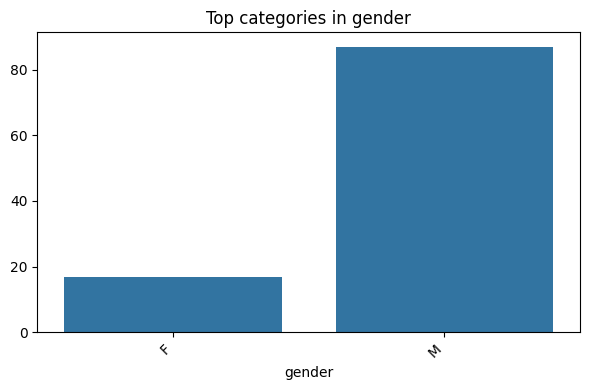

plotting the distribution for attribute: birth_date, else branch (Categorical)


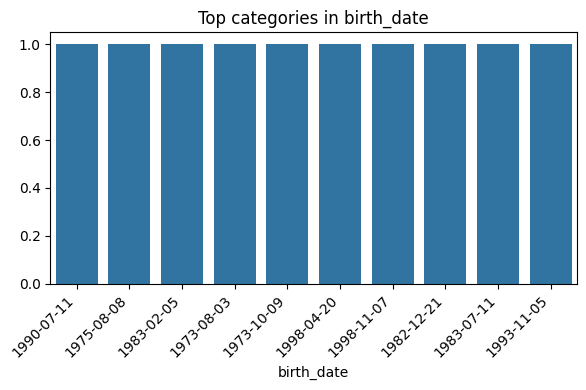

plotting the distribution for attribute: birth_place, else branch (Categorical)


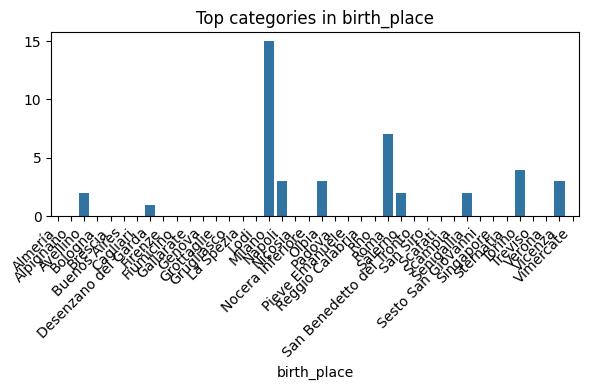

plotting the distribution for attribute: nationality, else branch (Categorical)


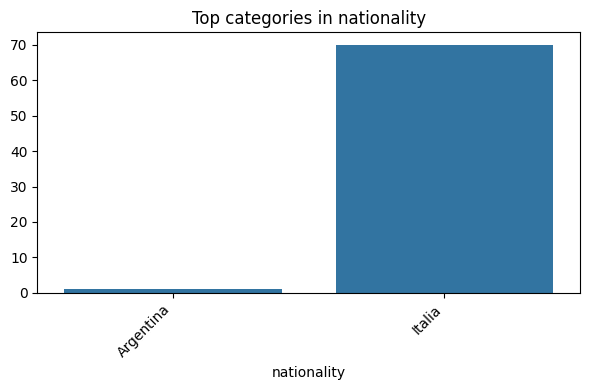

plotting the distribution for attribute: description, else branch (Categorical)


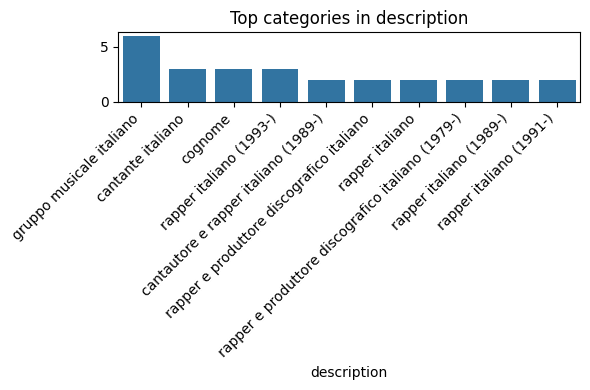

plotting the distribution for attribute: active_start, else branch (Categorical)


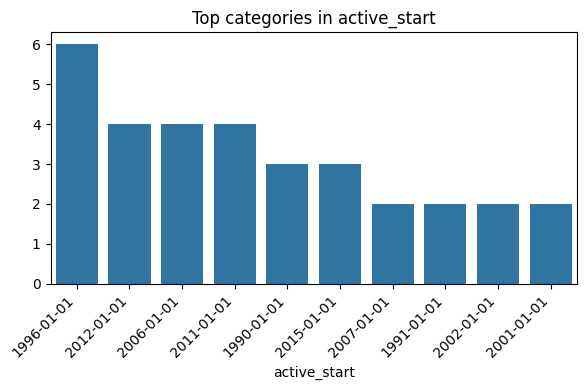

plotting the distribution for attribute: active_end, if branch (Numerical)


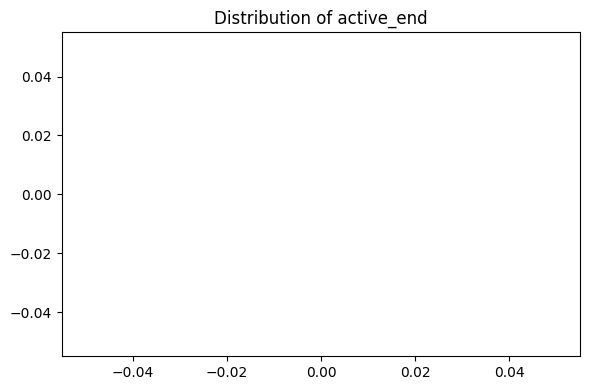

plotting the distribution for attribute: province, else branch (Categorical)


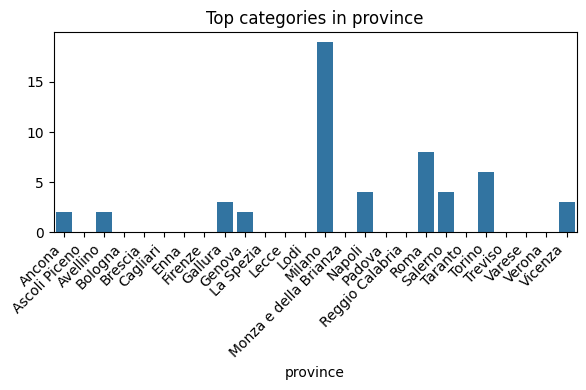

plotting the distribution for attribute: region, else branch (Categorical)


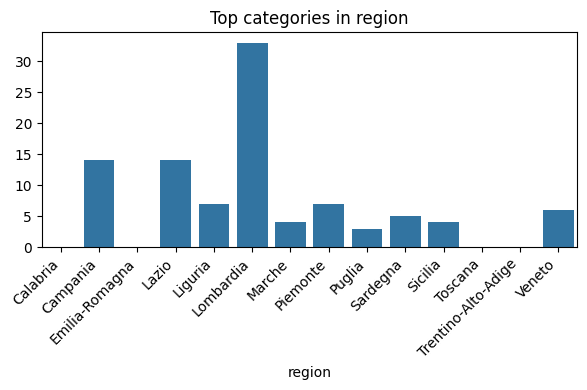

plotting the distribution for attribute: country, else branch (Categorical)


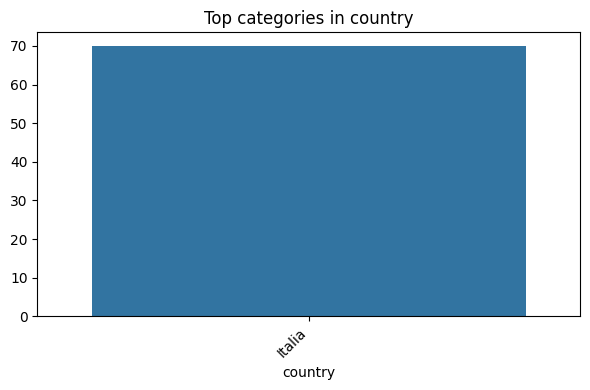

plotting the distribution for attribute: latitude, if branch (Numerical)


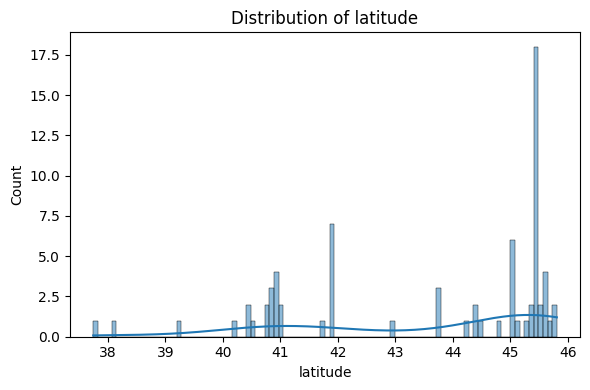

plotting the distribution for attribute: longitude, if branch (Numerical)


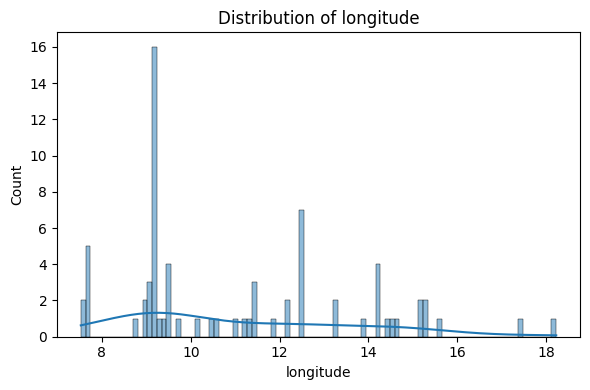

In [41]:
for col in df_artists.columns:
    plt.figure(figsize=(6,4))
    
    # --- Check for Numerical Columns (includes float64, int64, and Nullable Int64) ---
    # Using .kind in 'fi' is a reliable way to check for all float and integer types
    if df_artists[col].dtype.kind in 'fi': 
        print(f"plotting the distribution for attribute: {col}, if branch (Numerical)")
        
        data_to_plot = df_artists[col].dropna()
            
        sns.histplot(data_to_plot, kde=True, bins = 100)
        plt.title(f'Distribution of {col}')

    # --- Handle Categorical/Object Columns, using try/except for unhashable types ---
    # We use a try/except to catch the 'unhashable type: list' error gracefully
    else:
        try:
            print(f"plotting the distribution for attribute: {col}, else branch (Categorical)")
            
            # The error occurs here if the column contains Python lists
            counts = df_artists[col].value_counts().head(10)
            
            # Only proceed if there are values to plot
            if not counts.empty:
                sns.barplot(x=counts.index, y=counts.values)
                plt.title(f'Top categories in {col}')
                plt.xticks(rotation=45, ha='right')
            else:
                print(f"Skipping categorical plot for {col}: Value counts were empty.")

        except TypeError as e:
            # This handles the 'TypeError: unhashable type: 'list'' gracefully
            if 'unhashable type' in str(e):
                print(f"Skipping plot for {col}: Column contains unhashable types (e.g., Python lists).")
            else:
                # Re-raise any other unexpected TypeErrors
                raise e

    plt.tight_layout()
    plt.show()

The preceding visual analysis of attribute distributions has successfully illuminated several data quality issues, specifically the presence of erroneous values. These include instances such as:

* Temporal Inconsistencies: Values for the year attribute that fall outside the reasonable bounds defined by an artist's active_start and the current date.

* Domain Violations: Values for the popularity attribute that exceed its established domain maximum of 100.

These specific data integrity issues will be formally addressed and rectified in the subsequent Data Preparation phase. 

For the current Data Understanding phase, our objective remains strictly observational: to characterize the data's shape and quality without enacting any permanent modifications.We will now proceed with a preliminary, univariate outlier detection step. This involves plotting boxplots for each numerical attribute to visually quantify the number of data instances that fall outside the traditional whisker boundaries (typically defined by $1.5 \times \text{IQR}$). This process will yield a clearer, attribute-by-attribute assessment of the prevalence and extremity of outliers within the dataset.

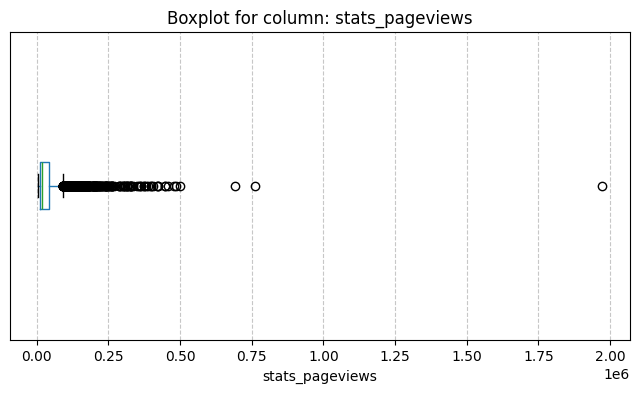

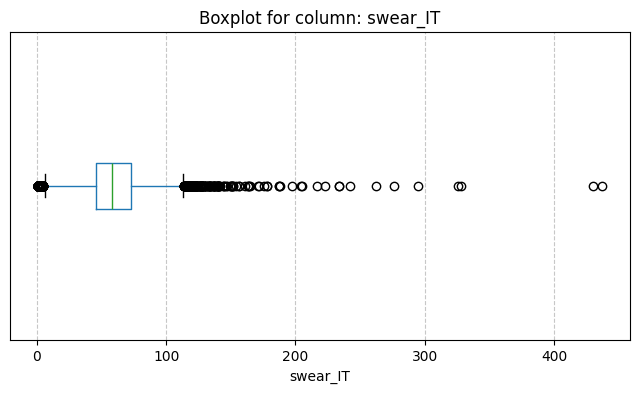

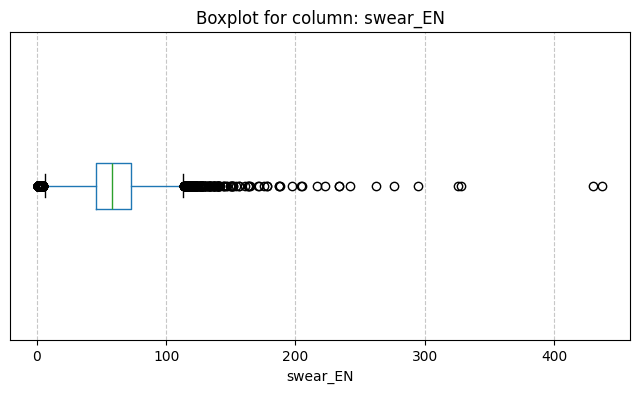

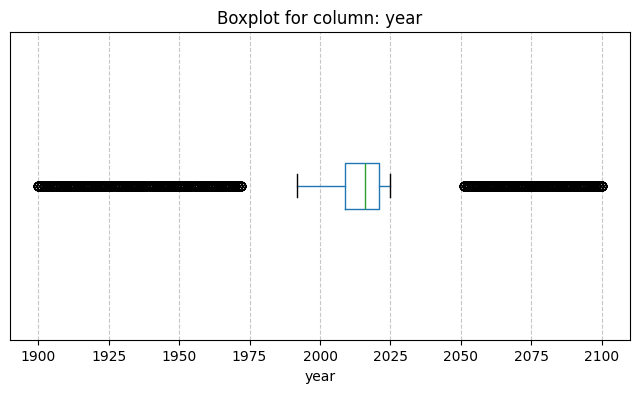

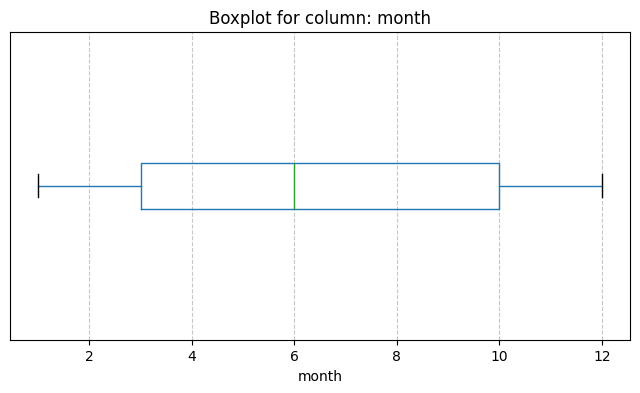

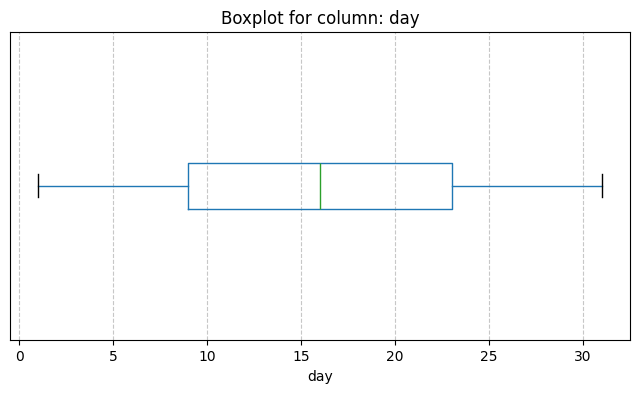

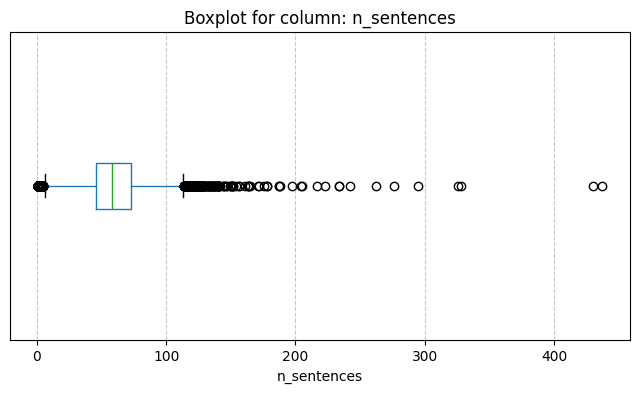

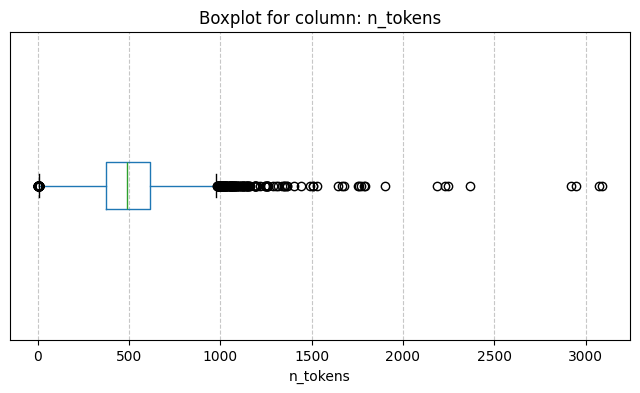

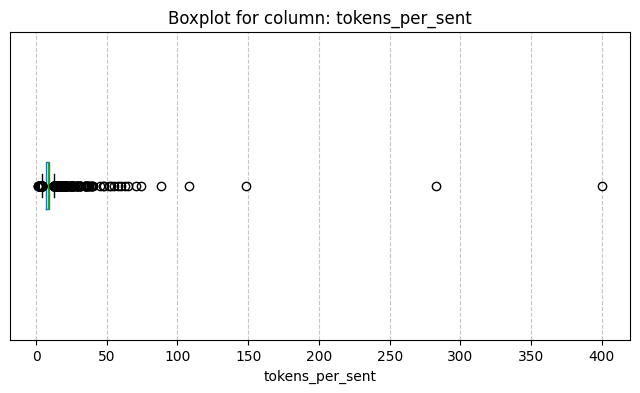

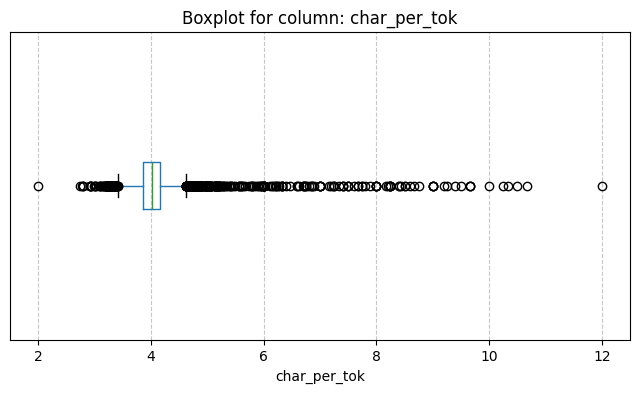

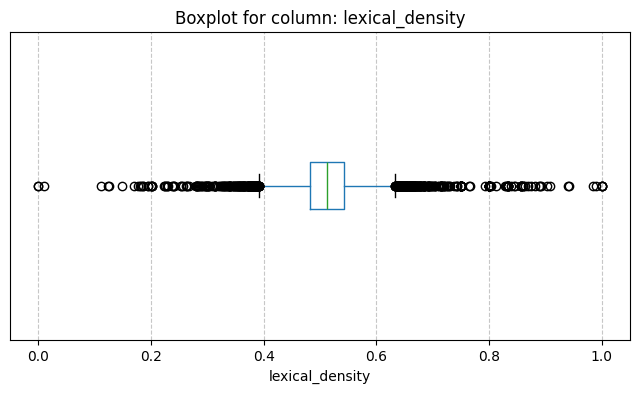

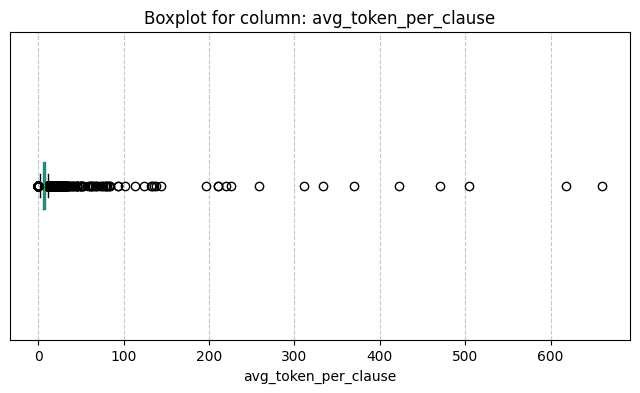

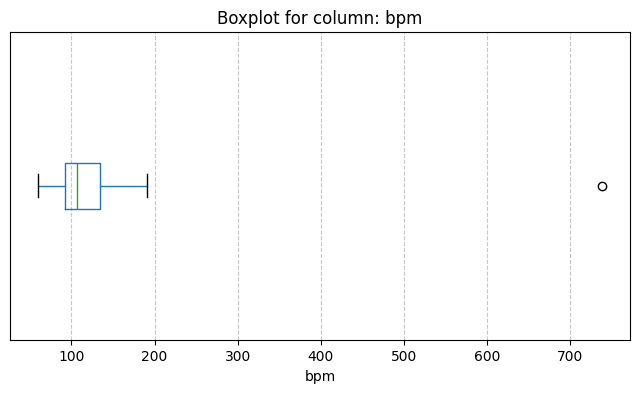

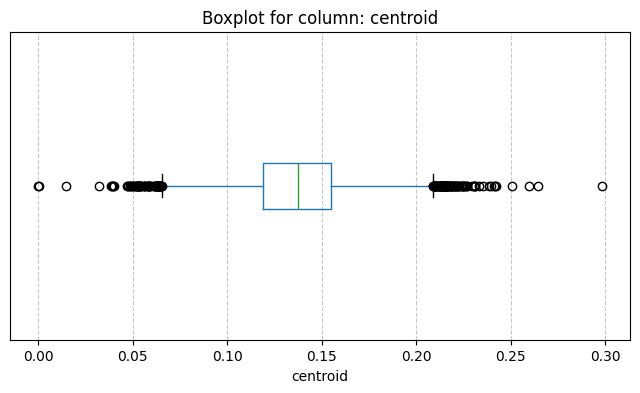

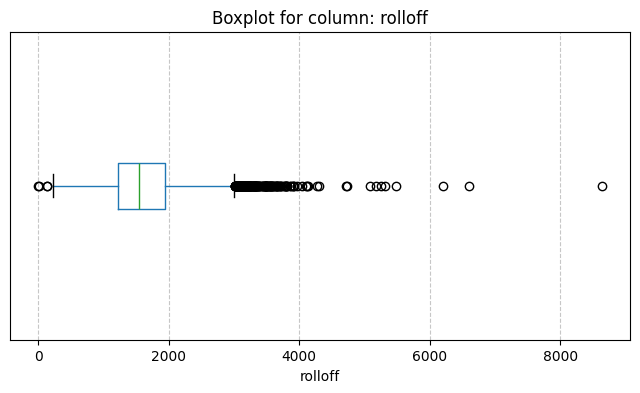

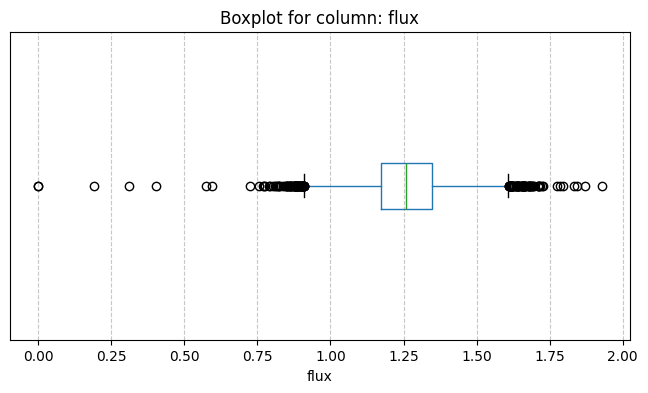

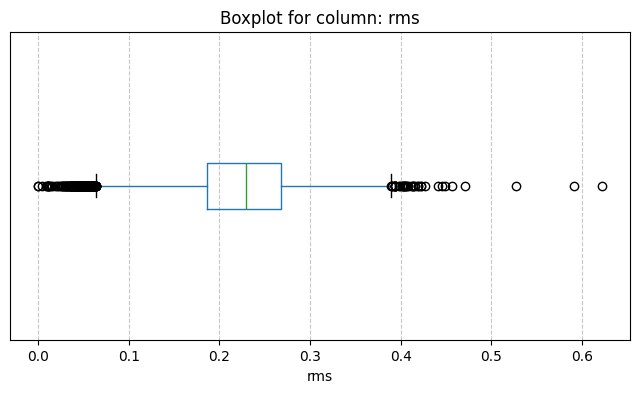

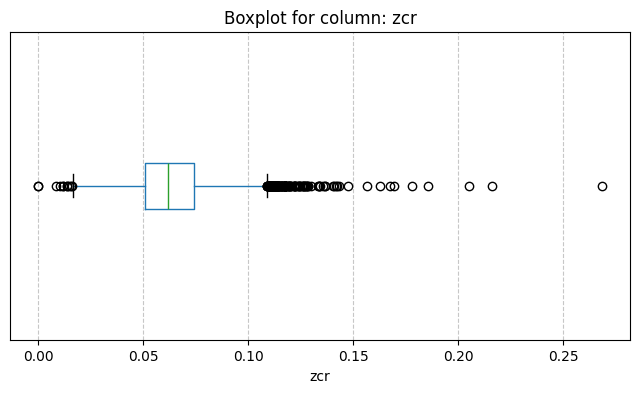

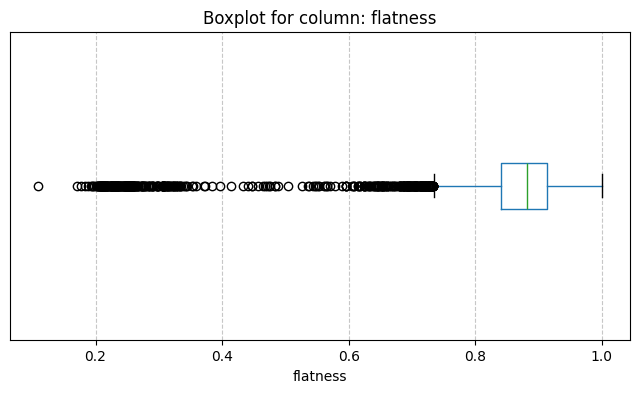

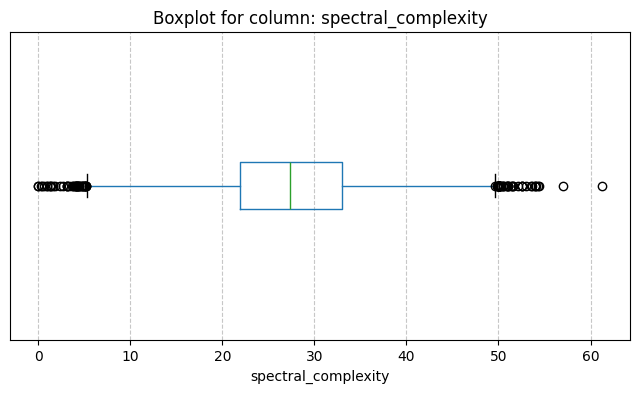

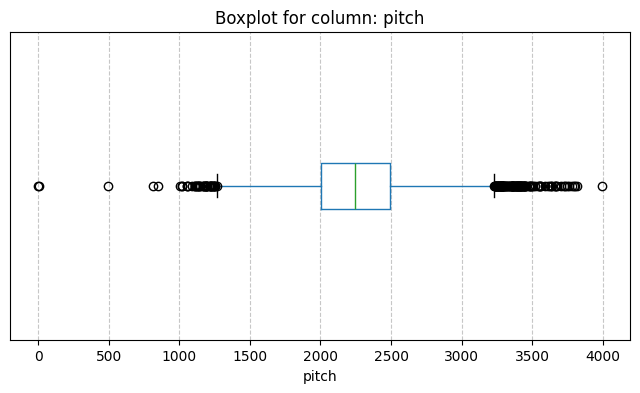

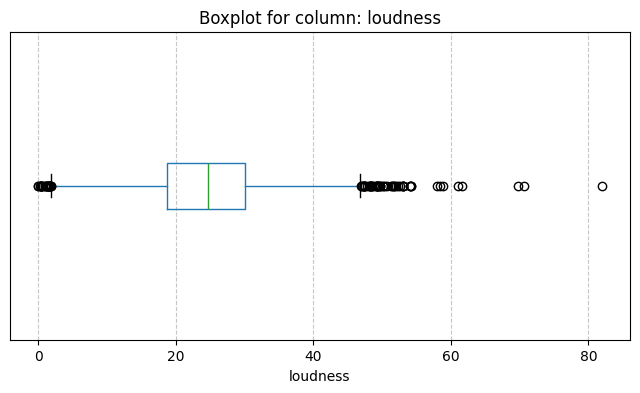

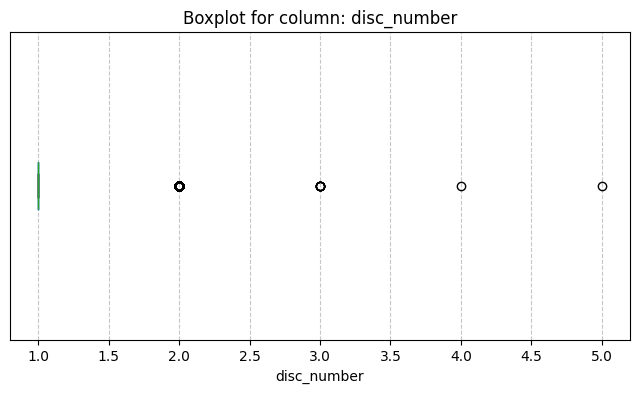

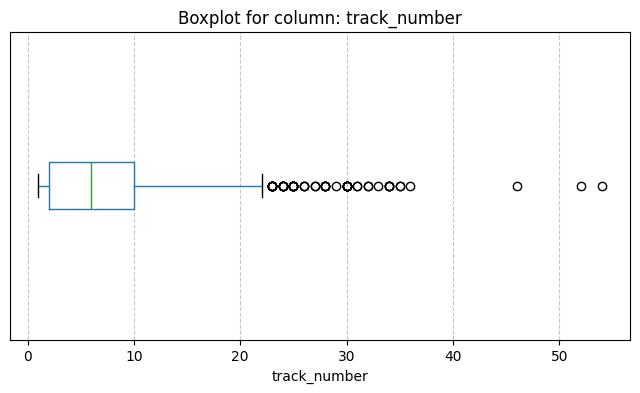

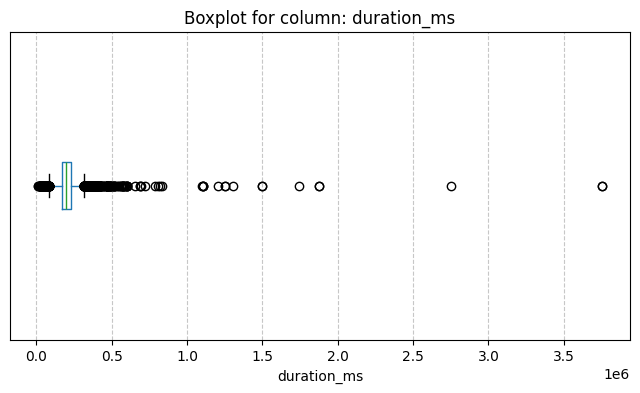

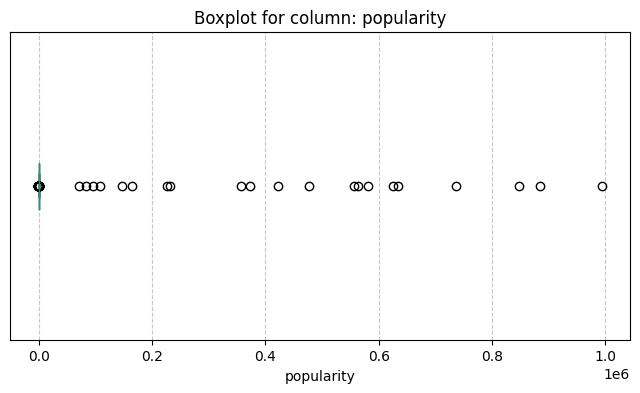

In [42]:
# Seleziona solo le colonne numeriche
df_numeric = df_tracks.select_dtypes(include=np.number)

# Scorri ogni colonna numerica e crea un boxplot separato
for col in df_numeric.columns:
    
    # Crea un nuovo grafico per la colonna corrente
    plt.figure(figsize=(8, 4))
    
    # Genera il boxplot. L'argomento vert=False lo rende orizzontale, più facile da leggere
    df_numeric.boxplot(column=col, vert=False)
    
    # Personalizzazione
    plt.title(f"Boxplot for column: {col}")
    plt.xlabel(col)
    plt.yticks([]) # Nasconde l'etichetta dell'asse Y (che non serve in un boxplot singolo)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    plt.show()

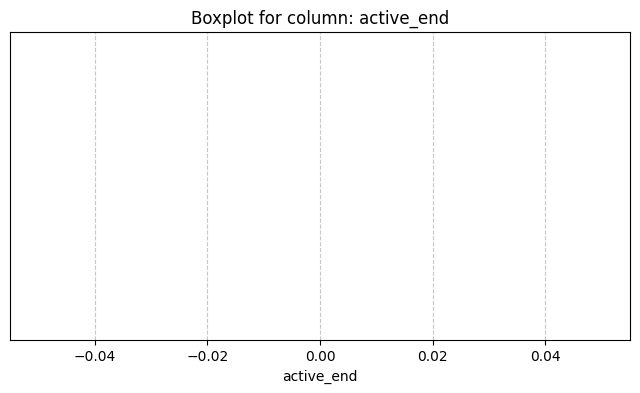

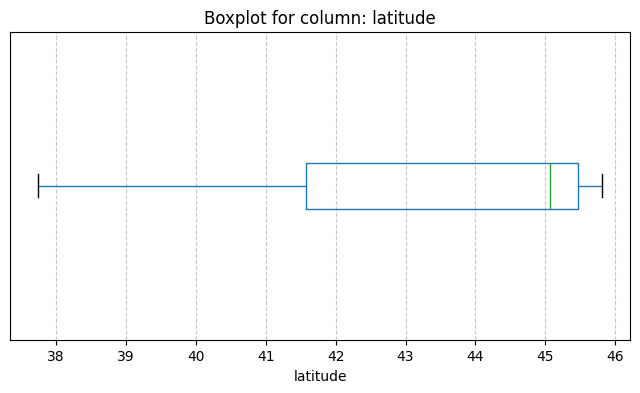

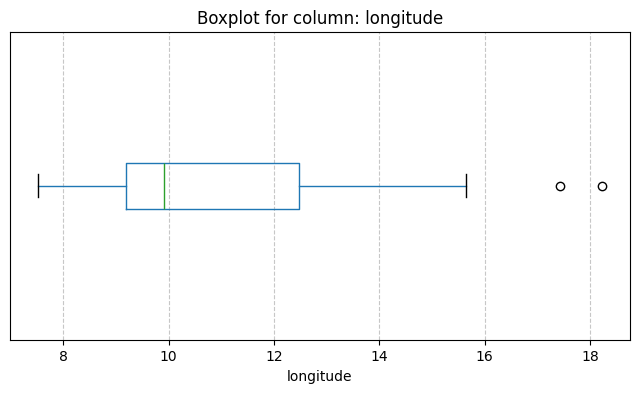

In [43]:
# Seleziona solo le colonne numeriche
df_numeric = df_artists.select_dtypes(include=np.number)

# Scorri ogni colonna numerica e crea un boxplot separato
for col in df_numeric.columns:
    
    # Crea un nuovo grafico per la colonna corrente
    plt.figure(figsize=(8, 4))
    
    # Genera il boxplot. L'argomento vert=False lo rende orizzontale, più facile da leggere
    df_numeric.boxplot(column=col, vert=False)
    
    # Personalizzazione
    plt.title(f"Boxplot for column: {col}")
    plt.xlabel(col)
    plt.yticks([]) # Nasconde l'etichetta dell'asse Y (che non serve in un boxplot singolo)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    plt.show()

## 🔗 Pairwise Correlation Analysis: Uncovering Feature Relationships

Pairwise correlation analysis is a critical step in **Data Understanding** and **Exploratory Data Analysis (EDA)**. It quantifies the degree to which two different features in the dataset are related or co-vary. Understanding these relationships is vital for feature selection, model building (by avoiding multicollinearity), and gaining substantive insights into the data's structure.

We analyze feature relationships using two primary methods: **Pearson's $r$** and **Spearman's $\rho$ (rho)**.

---

### 1. Pearson's Correlation Coefficient ($r$)

Pearson's $r$ measures the **linear relationship** between two continuous, normally distributed variables. It assesses how well the data points fit a straight line.

* **Range:** The coefficient is a value between **-1.0 and +1.0**.
    * **$\mathbf{r \approx +1.0}$**: Strong positive linear correlation (variables increase together).
    * **$\mathbf{r \approx -1.0}$**: Strong negative linear correlation (as one increases, the other decreases).
    * **$\mathbf{r \approx 0}$**: Weak or no linear correlation.

* **Caveat:** Pearson's $r$ is sensitive to outliers and only detects linear relationships; non-linear but strong relationships (e.g., a perfect curve) would result in a value near zero.

---

### 2. Spearman's Rank Correlation Coefficient ($\rho$)

Spearman's $\rho$ is a **non-parametric** measure that assesses the **monotonic relationship** between the ranked values of two variables. It determines if the variables tend to change together, regardless of whether that relationship is strictly linear.

* **Method:** The original values are converted to their **ranks** (1st, 2nd, 3rd, etc.), and the standard Pearson correlation is applied to these ranks.
* **Utility:**
    * It is more **robust to outliers** than Pearson's.
    * It is suitable for **ordinal data** (data that has a clear order, like 'track number' or a rating scale).
    * It effectively captures non-linear, but consistent, relationships.

---

### 🖼️ Correlation Matrix Visualization

Both Pearson and Spearman coefficients are typically displayed in a **Heatmap**  visualization.

In this notebook, we generate correlation matrices using both methods to provide a comprehensive view of the feature relationships:

| Matrix | Purpose | Key Insights |
| :--- | :--- | :--- |
| **Pearson Matrix** | To identify **strong linear relationships** between continuous audio and linguistic features (e.g., `loudness` vs. `rms`). | Indicates direct, straight-line dependencies that may be useful for linear modeling. |
| **Spearman Matrix** | To identify **monotonic relationships** across all numerical and rank-based features (e.g., `track_number` vs. `popularity`). | Highlights trends, even if non-linear, which is crucial for features like `year` or `explicit` status. |

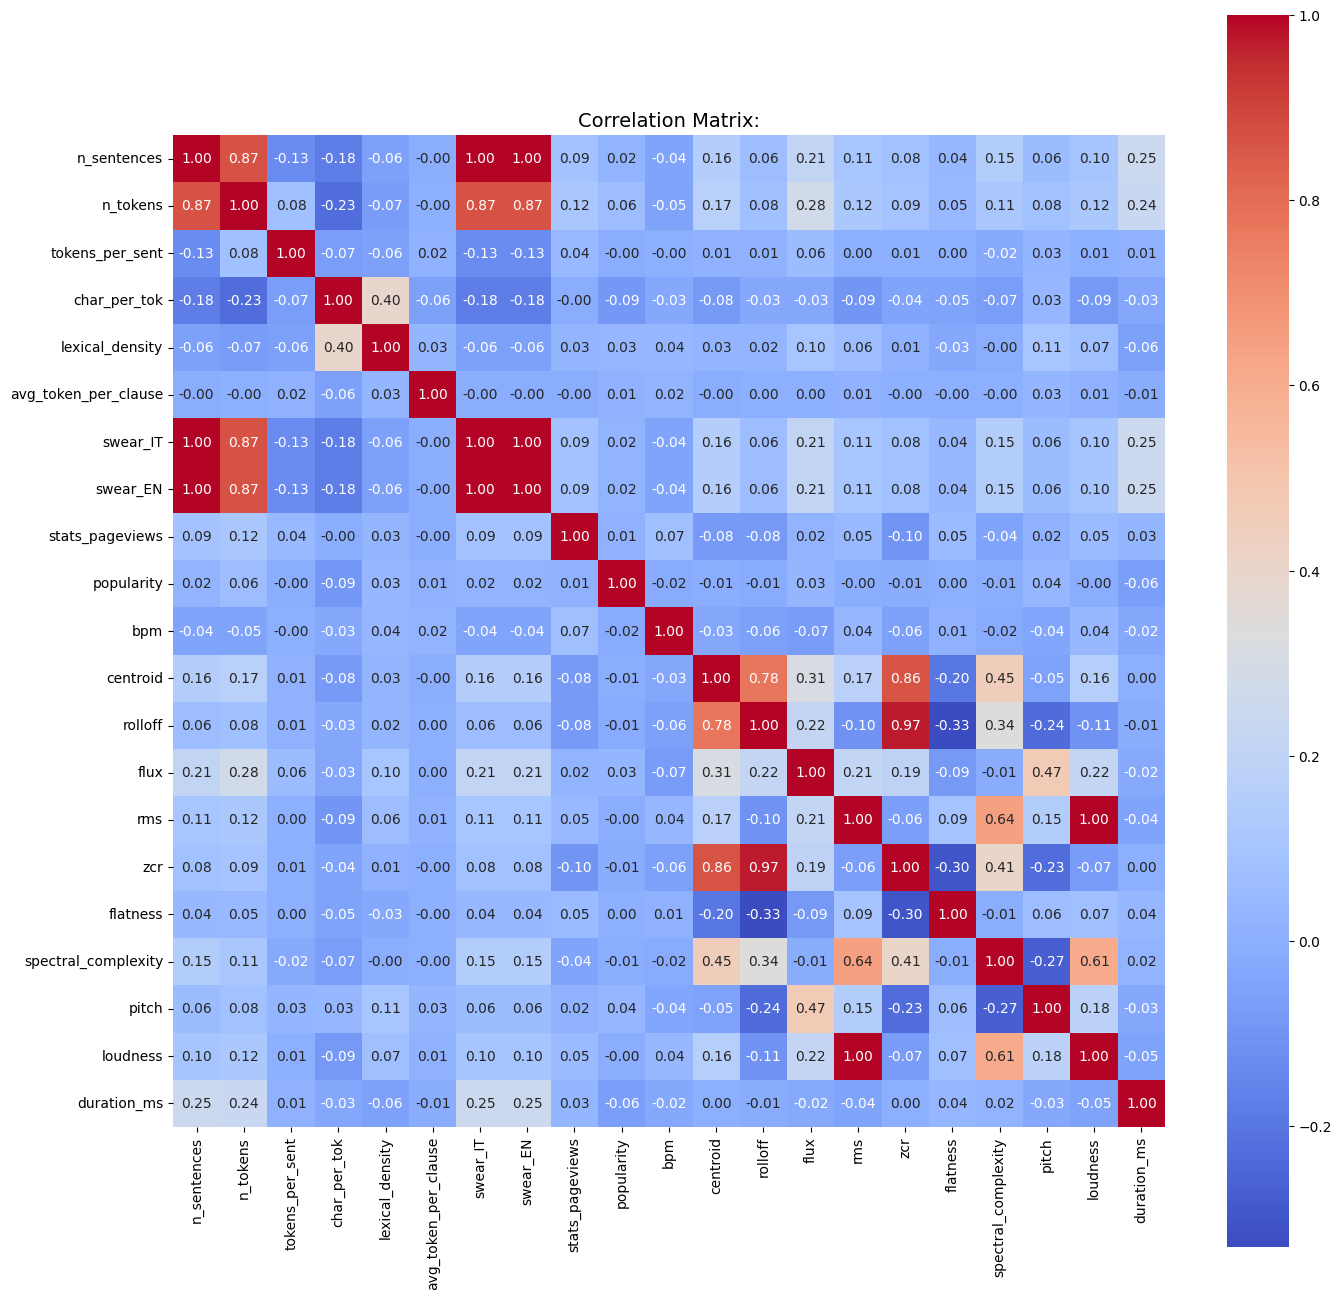

In [44]:
# 1. Define the list of meaningful numeric columns you want to plot
features = [
    'n_sentences',
    'n_tokens',
    'tokens_per_sent',
    'char_per_tok',
    'lexical_density',
    'avg_token_per_clause',
    'swear_IT',
    'swear_EN',
    'stats_pageviews',
    'popularity',
    'bpm',
    'centroid',
    'rolloff',
    'flux',
    'rms',
    'zcr',
    'flatness',
    'spectral_complexity',
    'pitch',
    'loudness',
    'duration_ms',
]

# 2. Select the subset of data
df_subset = df_tracks[features]

# 3. Calculate the correlation matrix on the subset
corr_matrix_subset = df_subset.corr()

# 4. Plot the results
plt.figure(figsize=(16, 16)) # Use a smaller figure size for fewer columns
sns.heatmap(corr_matrix_subset, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix:", fontsize=14)
plt.show()

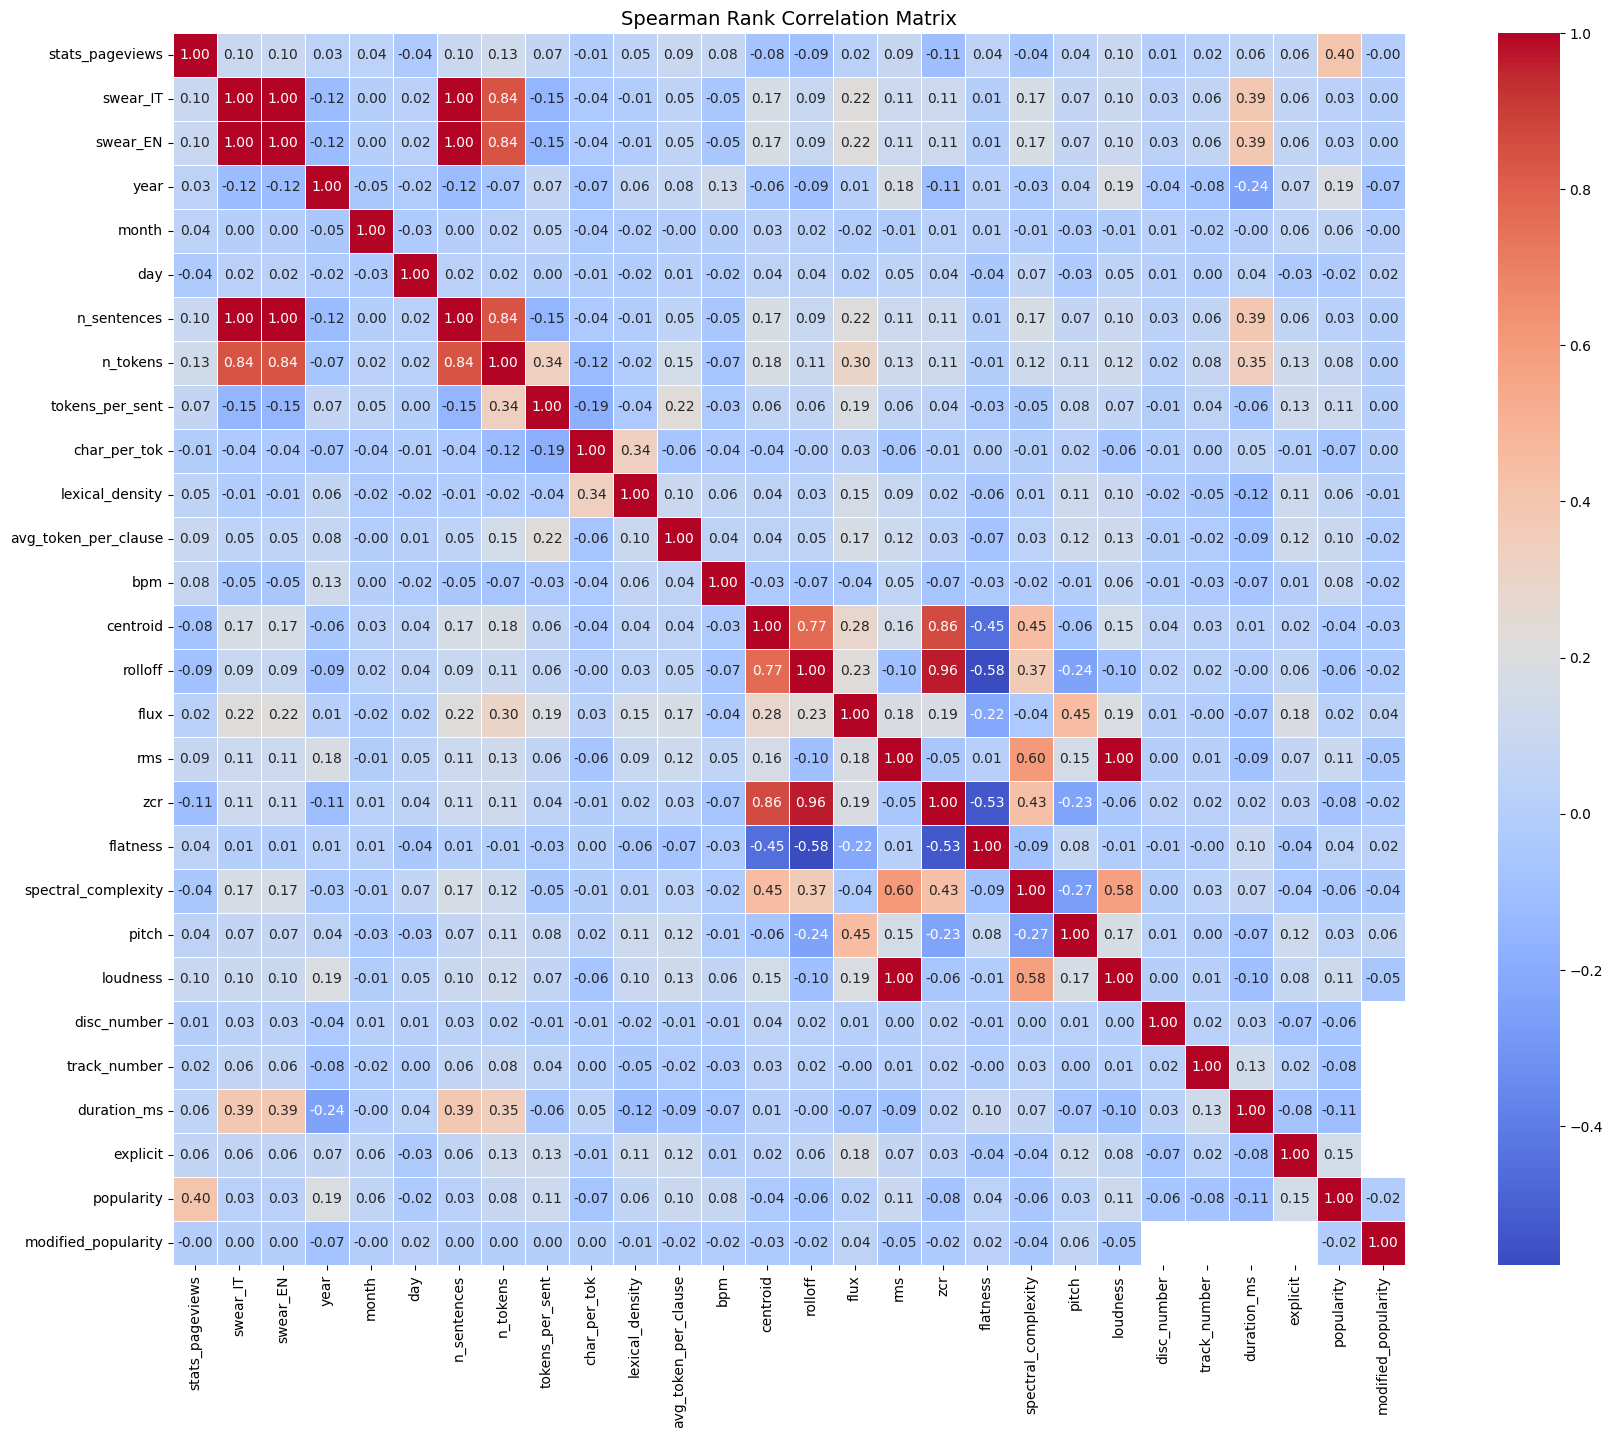

In [45]:
# 2. Calculate the correlation matrix using the Spearman method
# numeric_only=False is used here since we are explicitly selecting all desired numeric and boolean columns
corr_matrix_spearman = df_tracks.corr(method='spearman', numeric_only=True)

# 3. Plot the results
plt.figure(figsize=(24, 16))
sns.heatmap(
    corr_matrix_spearman,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=.5
)
plt.title("Spearman Rank Correlation Matrix", fontsize=14)
plt.show()

In [46]:
df_artists.to_csv('dataset/artists_data_casted.csv', sep = ';')
df_tracks.to_csv('dataset/tracks_data_casted.csv', sep = ',')